# Cập nhật package list và cài build tools 

In [1]:
!sudo apt-get update -q
!sudo apt-get install -y -q build-essential wget git
!g++ --version

Get:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:2 https://cli.github.com/packages stable InRelease [3,917 B]
Get:3 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:5 https://cli.github.com/packages stable/main amd64 Packages [354 B]
Get:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:7 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:9 http://security.ubuntu.com/ubuntu jammy-security/restricted amd64 Packages [7,228 kB]
Get:10 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [10.4 MB]
Get:11 http://security.ubuntu.com/ubuntu jammy-security/main amd64 Packages [4,028 kB]
Get:12 http://security.ubuntu.com/ubuntu jammy-security/universe amd64 Packages [1,307 kB]
Get:13 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 k

# Tạo thư mục gốc cho toàn bộ experiment

In [2]:
!mkdir -p /kaggle/working/experiments
%cd /kaggle/working/experiments

/kaggle/working/experiments


# THƯ VIỆN & CẤU HÌNH (ABLATION — CVR ONLY)


In [3]:
!pip install -q openml scikit-learn pandas numpy

import os
import time
import subprocess
import re
import warnings
import numpy as np
import pandas as pd
import openml
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MaxAbsScaler
from sklearn.datasets import dump_svmlight_file, load_svmlight_file

EXPERIMENTS_DIR = '/kaggle/working/experiments'
DATA_DIR = os.path.join(EXPERIMENTS_DIR, 'data')
os.makedirs(DATA_DIR, exist_ok=True)
RANDOM_STATE = 42
openml.config.apikey = ''

EXPERIMENT_CONFIG = {
    'census_housing':    {'task': 'regression', 'n_features': 121, 'expected_N': 22732,  'pcts': [10, 30, 50, 90]},
}

TMP_DIR = os.path.join(EXPERIMENTS_DIR, 'tmp')
os.makedirs(TMP_DIR, exist_ok=True)

# CVR binaries
CVR_TRAIN_BIN       = os.path.join(EXPERIMENTS_DIR, 'cvr_train')
CVR_TRAIN_ABLATION  = os.path.join(EXPERIMENTS_DIR, 'cvr_train_ablation')

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.4/160.4 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.8/93.8 kB 4.3 MB/s eta 0:00:00


# BIÊN DỊCH CVR

In [4]:
%%writefile /kaggle/working/experiments/cvr_train.cpp
#pragma GCC optimize("O3,unroll-loops")
#pragma GCC target("avx2,bmi,bmi2,lzcnt,popcnt")

#include <iostream>
#include <vector>
#include <cmath>
#include <numeric>
#include <algorithm>
#include <random>
#include <unordered_set>
#include <fstream>
#include <sstream>
#include <string>
#include <iomanip>
using namespace std;

class CoreVectorRegression {
public:
    double C, mu, gamma, epsilon;
    int max_iter;
    double b, epsilon_bar;
    vector<int>    core_idx;
    vector<double> alpha;
    vector<vector<double>> core_cache;
    vector<double> diag_all, delta_all;

private:
    // --- RBF kernel ----------------------------------------------------------
    inline double rbf(const vector<double>& x1, const vector<double>& x2) const {
        double sq = 0;
        const double* p1 = x1.data();
        const double* p2 = x2.data();
        for (int i = 0, n = (int)x1.size(); i < n; ++i) {
            double d = p1[i]-p2[i]; sq += d*d;
        }
        return exp(-gamma * sq);
    }

    // --- SMO solver cho CCMEB trên simplex -----------------------------------
    //
    // Bài toán: max α'c̃ − α'K̃α  s.t. α≥0, Σα=1
    //   c̃[i] = d_S[i]/2  (linear term của CCMEB dual)
    //
    // Gradient (dấu âm): g[i] = (K̃α)[i] − d_S[i]/2  (g = −∇f)
    //
    // Chọn:  i = argmax{g[t] : α[t]>0}  (active var với grad nhỏ nhất → giảm)
    //        j = argmin{g[t]}             (var với grad lớn nhất → tăng)
    // Dừng:  max_g − min_g < tol
    //
    // Sau khi gọi: g chứa gradient cuối (dùng để tính quad_term O(k))
    //
    void solve_smo(int k, double reg_diag, const vector<double>& d_S,
                   vector<double>& g, double tol,
                   const vector<vector<double>>& K_core) {
        int n = 2 * k;

        // -- Warm-start: khởi tạo g từ alpha hiện tại -------------------------
        // g[i] = -d_S[i]/2 + Σ_{j: α[j]>0} K̃[i][j]*α[j]
        for (int i = 0; i < n; ++i) g[i] = -0.5 * d_S[i];

        for (int j = 0; j < n; ++j) {
            if (alpha[j] < 1e-12) continue;
            int cj = j >> 1, sj = j & 1;
            const double* cj_row = K_core[cj].data();
            double aj = alpha[j];

            for (int ct = 0; ct < k; ++ct) {
                // K̃[2ct, j] và K̃[2ct+1, j]
                double kv   = cj_row[ct] + 1.0;
                double diag = (ct == cj) ? reg_diag : 0.0;
                if (sj == 0) {
                    g[2*ct]   += (kv + diag) * aj;
                    g[2*ct+1] += (-kv)        * aj;
                } else {
                    g[2*ct]   += (-kv)        * aj;
                    g[2*ct+1] += (kv + diag)  * aj;
                }
            }
        }

        // -- Vòng lặp SMO -----------------------------------------------------
        for (int iter = 0; iter < 2000000; ++iter) {
            int ii = -1, ji_min = -1;
            double max_g = -1e18, min_g = 1e18;

            for (int t = 0; t < n; ++t) {
                if (alpha[t] > 1e-12 && g[t] > max_g) { max_g = g[t]; ii = t; }
                if (g[t] < min_g)                      { min_g = g[t]; ji_min = t; }
            }
            // ★ Điều kiện dừng với tol=1e-6
            if (ii < 0 || ji_min < 0 || max_g - min_g < tol) break;

            // ★ CHUẨN LIBSVM: WSS2 (Second-Order Working Set Selection)
            int ji = -1;
            double max_obj = -1e18;
            int ci = ii>>1;
            const double* ci_row = K_core[ci].data();
            double kii_ws = ci_row[ci] + 1.0 + reg_diag;
            for (int t = 0; t < n; ++t) {
                if (max_g - g[t] > 0) {
                    int ct = t>>1;
                    double ktt = K_core[ct][ct] + 1.0 + reg_diag;
                    double kit_base = ci_row[ct] + 1.0;
                    double kit = kit_base;
                    if ((ii&1) != (t&1)) kit = -kit_base;
                    else if (ci == ct) kit += reg_diag;

                    double quad_coef = kii_ws + ktt - 2.0 * kit;
                    if (quad_coef <= 1e-12) quad_coef = 1e-12;

                    double obj = (max_g - g[t]) * (max_g - g[t]) / quad_coef;
                    if (obj > max_obj) {
                        max_obj = obj;
                        ji = t;
                    }
                }
            }
            if (ji < 0) ji = ji_min;

            // Phần tử đường chéo K̃[ii,ii], K̃[ji,ji] và K̃[ii,ji]
            int cj = ji>>1, sj = ji&1;
            int si = ii&1;

            double kii = K_core[ci][ci] + 1.0 + reg_diag;
            double kjj = K_core[cj][cj] + 1.0 + reg_diag;
            double kij_base = ci_row[cj] + 1.0;
            double kij;
            if (si == sj) {
                kij = kij_base + (ci == cj ? reg_diag : 0.0);
            } else {
                kij = -kij_base;
            }

            double eta = kii + kjj - 2.0 * kij;
            if (eta < 1e-12) eta = 1e-12;
            double lam = min((max_g - g[ji]) / eta, alpha[ii]);
            if (lam < 1e-12) break;

            alpha[ii] -= lam;
            alpha[ji] += lam;

            // Cập nhật gradient: g[t] += λ*(K̃[t,ji] − K̃[t,ii])
            const double* cj_row2 = K_core[cj].data();
            for (int ct = 0; ct < k; ++ct) {
                double kvi  = ci_row[ct] + 1.0;
                double kvj  = cj_row2[ct] + 1.0;
                double di   = (ct == ci) ? reg_diag : 0.0;
                double dj   = (ct == cj) ? reg_diag : 0.0;

                double Ki_pos = (si==0) ? (kvi+di) : (-kvi);
                double Ki_neg = (si==0) ? (-kvi)   : (kvi+di);
                double Kj_pos = (sj==0) ? (kvj+dj) : (-kvj);
                double Kj_neg = (sj==0) ? (-kvj)   : (kvj+dj);

                g[2*ct]   += lam * (Kj_pos - Ki_pos);
                g[2*ct+1] += lam * (Kj_neg - Ki_neg);
            }
        }

        // Normalize về simplex
        double sum = 0.0;
        for (double& a : alpha) { a = max(0.0, a); sum += a; }
        if (sum > 0) for (double& a : alpha) a /= sum;
    }

public:
    CoreVectorRegression(double C_, double mu_, double gamma_,
                         double eps_, int max_iter_)
        : C(C_), mu(mu_), gamma(gamma_), epsilon(eps_),
          max_iter(max_iter_), b(0), epsilon_bar(0) {}

    void fit(const vector<vector<double>>& X, const vector<double>& y) {
        int m = (int)X.size();

        // -- Tiền xử lý: diag_all, delta_all, eta_global ----------------------
        diag_all.assign(2*m, 0.0);
        delta_all.assign(2*m, 0.0);
        vector<double> lin_all(2*m);
        double reg_diag = mu * m / C;
        double min_lin = 1e18, max_diag = -1e18;

        for (int i = 0; i < m; ++i) {
            double dv = 2.0 + reg_diag;         // k(x,x)=1 → k+1=2 + reg
            diag_all[i] = diag_all[i+m] = dv;
            lin_all[i]   =  (2.0/C) * y[i];
            lin_all[i+m] = -(2.0/C) * y[i];
            min_lin  = min({min_lin,  lin_all[i], lin_all[i+m]});
            max_diag = max(max_diag, dv);
        }

        double eta_global = max_diag - min_lin + 1.0;
        for (int i = 0; i < 2*m; ++i)
            delta_all[i] = max(-diag_all[i] + eta_global + lin_all[i], 0.0);

        // -- Khởi tạo 2 core vector ngẫu nhiên --------------------------------
        mt19937 rng(42);
        vector<int> pool(m); iota(pool.begin(), pool.end(), 0);
        shuffle(pool.begin(), pool.end(), rng);
        core_idx = {pool[0], pool[1]};
        unordered_set<int> core_set(core_idx.begin(), core_idx.end());

        for (int c : core_idx) {
            vector<double> row(m);
            for (int i = 0; i < m; ++i) row[i] = rbf(X[c], X[i]);
            core_cache.push_back(row);
        }
        alpha.assign(4, 0.25);

        vector<vector<double>> K_core(2, vector<double>(2));
        for(int i=0; i<2; ++i) {
            for(int j=0; j<2; ++j) {
                K_core[i][j] = core_cache[i][core_idx[j]];
            }
        }

        vector<double> g; // gradient vector (tái sử dụng qua các vòng lặp)

        // -- Vòng lặp chính CVR ------------------------------------------------
        for (int outer = 0; outer < max_iter; ++outer) {
            int k = (int)core_idx.size();
            int n = 2 * k;

            // Xây d_S trong O(k)
            vector<double> d_S(n);
            for (int i = 0; i < k; ++i) {
                int gi      = core_idx[i];
                double sk   = core_cache[i][gi] + 1.0 + reg_diag; // K̃_ii
                d_S[2*i]    = sk + delta_all[gi]   - eta_global;
                d_S[2*i+1]  = sk + delta_all[gi+m] - eta_global;
            }

            // -- Giải inner QP bằng SMO (tol=1e-6, warm-start) ----------------
            g.assign(n, 0.0);
            solve_smo(k, reg_diag, d_S, g, 1e-6, K_core); // g trả về gradient cuối

            // -- Tính quad_term trong O(k) bằng gradient -----------------------
            //   Tại điểm hội tụ: g[i] = (K̃α)[i] − d_S[i]/2
            //   → quad_term = α'K̃α = Σ α[i]*(g[i] + d_S[i]/2)
            double sum_ag = 0.0, sum_adS = 0.0;
            for (int i = 0; i < n; ++i) {
                sum_ag  += alpha[i] * g[i];
                sum_adS += alpha[i] * d_S[i];
            }
            double quad_term = sum_ag + 0.5 * sum_adS;  // = α'K̃α  O(k)!

            // b = C * Σ(α_i − α*_i)
            b = 0.0;
            for (int i = 0; i < k; ++i) b += C * (alpha[2*i] - alpha[2*i+1]);

            // epsilon_bar
            double linear_term = 0.0;
            for (int i = 0; i < n; ++i) {
                int ci = i>>1, si = i&1;
                linear_term += alpha[i] * (si==0 ? y[core_idx[ci]] : -y[core_idx[ci]]);
            }
            epsilon_bar = max(linear_term - C * quad_term, 0.0);

            double c_norm_sq = quad_term;

            // R² trong O(k): R² = Σ α[i]*(d_S[i]+η) − quad_term = 0.5*Σα·dS + η − Σα·g
            // -- Tính R2 và threshold
            double R2 = max(0.5*sum_adS + eta_global - sum_ag, 1e-12);
            double threshold = pow((1.0 + epsilon) * sqrt(R2), 2);

            // -- Tiền tính sum_diff
            double sum_diff = 0.0;
            for (int j = 0; j < k; ++j) sum_diff += alpha[2*j] - alpha[2*j+1];

            // Hàm tính on-demand tiết kiệm O(km)
            auto get_kt = [&](int idx) {
                double v = sum_diff;
                for (int j = 0; j < k; ++j) {
                    double ad = alpha[2*j] - alpha[2*j+1];
                    if (abs(ad) > 1e-12) v += core_cache[j][idx] * ad;
                }
                return v;
            };

            // -- 59-point probabilistic speedup --------------------------------
            vector<int> non_core;
            non_core.reserve(m - k);
            for (int i = 0; i < m; ++i) if (!core_set.count(i)) non_core.push_back(i);

            bool added = false;
            int ss = min(59, (int)non_core.size());
            if (ss > 0) {
                shuffle(non_core.begin(), non_core.end(), rng);
                double bd = -1; int bi = -1;
                for (int s = 0; s < ss; ++s) {
                    int idx = non_core[s];
                    double v  = get_kt(idx);
                    double d0 = c_norm_sq - 2.0*v + diag_all[idx]   + delta_all[idx];
                    double d1 = c_norm_sq + 2.0*v + diag_all[idx+m] + delta_all[idx+m];
                    double d  = max(d0, d1);
                    if (d > threshold && d > bd) { bd = d; bi = idx; }
                }
                if (bi >= 0) {
                    core_idx.push_back(bi); core_set.insert(bi);
                    vector<double> row(m);
                    for (int i = 0; i < m; ++i) row[i] = rbf(X[bi], X[i]);
                    core_cache.push_back(row);
                    alpha.push_back(0.0); alpha.push_back(0.0);

                    int new_k = core_idx.size();
                    K_core.push_back(vector<double>(new_k));
                    for(int i=0; i<new_k-1; ++i) {
                        double val = core_cache[new_k-1][core_idx[i]];
                        K_core[new_k-1][i] = val;
                        K_core[i].push_back(val);
                    }
                    K_core[new_k-1][new_k-1] = core_cache[new_k-1][bi];

                    added = true;
                }
            }
            if (added) continue;

            // -- Full scan để tìm điểm vi phạm tệ nhất ------------------------
            double bd_all = -1; int bi_all = -1;
            for (int idx = 0; idx < m; ++idx) {
                if (core_set.count(idx)) continue;
                double v  = get_kt(idx);
                double d0 = c_norm_sq - 2.0*v + diag_all[idx]   + delta_all[idx];
                double d1 = c_norm_sq + 2.0*v + diag_all[idx+m] + delta_all[idx+m];
                double d  = max(d0, d1);
                if (d > threshold && d > bd_all) { bd_all = d; bi_all = idx; }
            }

            if (bi_all < 0) break; // Không còn vi phạm → hội tụ

            core_idx.push_back(bi_all); core_set.insert(bi_all);
            vector<double> row(m);
            for (int i = 0; i < m; ++i) row[i] = rbf(X[bi_all], X[i]);
            core_cache.push_back(row);
            alpha.push_back(0.0); alpha.push_back(0.0);

            int new_k = core_idx.size();
            K_core.push_back(vector<double>(new_k));
            for(int i=0; i<new_k-1; ++i) {
                double val = core_cache[new_k-1][core_idx[i]];
                K_core[new_k-1][i] = val;
                K_core[i].push_back(val);
            }
            K_core[new_k-1][new_k-1] = core_cache[new_k-1][bi_all];
        }
    }
};

// --- Load dữ liệu định dạng LIBSVM -------------------------------------------
bool load_libsvm(const string& path, int nf,
                 vector<vector<double>>& X, vector<double>& y) {
    ifstream f(path);
    if (!f.is_open()) return false;
    string line;
    while (getline(f, line)) {
        if (line.empty()) continue;
        stringstream ss(line);
        double lbl; ss >> lbl; y.push_back(lbl);
        vector<double> x(nf, 0.0); string tok;
        while (ss >> tok) {
            auto p = tok.find(':');
            if (p != string::npos) {
                int idx = stoi(tok.substr(0, p));
                if (idx >= 1 && idx <= nf) x[idx-1] = stod(tok.substr(p+1));
            }
        }
        X.push_back(x);
    }
    return true;
}

// --- Main --------------------------------------------------------------------
int main(int argc, char* argv[]) {
    if (argc < 8) return 1;
    string train_path = argv[1];
    int    nf      = stoi(argv[2]);
    double C       = stod(argv[3]);
    double mu      = stod(argv[4]);
    double gamma   = stod(argv[5]);
    double epsilon = stod(argv[6]);
    string out_path = argv[7];

    vector<vector<double>> X; vector<double> y;
    load_libsvm(train_path, nf, X, y);

    CoreVectorRegression model(C, mu, gamma, epsilon, 100000);
    model.fit(X, y);

    ofstream out(out_path);
    out << setprecision(10)
        << model.b << "\n"
        << model.epsilon_bar << "\n"
        << model.core_idx.size() << "\n";
    for (size_t i = 0; i < model.core_idx.size(); ++i)
        out << model.core_idx[i] << " "
            << C * (model.alpha[2*i] - model.alpha[2*i+1]) << "\n";
    out.close();
    return 0;
}

Writing /kaggle/working/experiments/cvr_train.cpp


In [5]:
!g++ -O3 -o /kaggle/working/experiments/cvr_train /kaggle/working/experiments/cvr_train.cpp -lm
!ls -la /kaggle/working/experiments/cvr_train

-rwxr-xr-x 1 root root 82232 Jun 22 23:49 /kaggle/working/experiments/cvr_train


## Compile CVR Ablation Variant

Biên dịch binary `cvr_train_ablation` với 3 tham số bổ sung:
- `sample_size`: Số mẫu ngẫu nhiên cho bước probabilistic speedup (mặc định 59). Giá trị 0 = bỏ qua bước probabilistic.
- `wss_mode`: 1 = WSS1 (first-order), 2 = WSS2 (second-order, mặc định).
- `smo_tol`: Tolerance cho SMO inner solver (mặc định 1e-6).

In [6]:
CVR_TRAIN_ABLATION = "/kaggle/working/experiments/cvr_train_ablation"

In [7]:
# %%writefile /kaggle/working/experiments/cvr_train_ablation.cpp

cpp_source = r'''
#pragma GCC optimize("O3,unroll-loops")
#pragma GCC target("avx2,bmi,bmi2,lzcnt,popcnt")

#include <iostream>
#include <vector>
#include <cmath>
#include <numeric>
#include <algorithm>
#include <random>
#include <unordered_set>
#include <fstream>
#include <sstream>
#include <string>
#include <iomanip>
using namespace std;

class CoreVectorRegression {
public:
    double C, mu, gamma, epsilon;
    int max_iter;
    int sample_size;       // Số mẫu cho probabilistic speedup (0 = bỏ qua)
    int wss_mode;          // 1 = WSS1 (first-order), 2 = WSS2 (second-order)
    double smo_tol;        // Tolerance cho SMO inner solver
    double b, epsilon_bar;
    vector<int>    core_idx;
    vector<double> alpha;
    vector<vector<double>> core_cache;
    vector<double> diag_all, delta_all;

private:
    inline double rbf(const vector<double>& x1, const vector<double>& x2) const {
        double sq = 0;
        const double* p1 = x1.data();
        const double* p2 = x2.data();
        for (int i = 0, n = (int)x1.size(); i < n; ++i) {
            double d = p1[i]-p2[i]; sq += d*d;
        }
        return exp(-gamma * sq);
    }

    void solve_smo(int k, double reg_diag, const vector<double>& d_S,
                   vector<double>& g, double tol,
                   const vector<vector<double>>& K_core) {
        int n = 2 * k;
        for (int i = 0; i < n; ++i) g[i] = -0.5 * d_S[i];
        for (int j = 0; j < n; ++j) {
            if (alpha[j] < 1e-12) continue;
            int cj = j >> 1, sj = j & 1;
            const double* cj_row = K_core[cj].data();
            double aj = alpha[j];
            for (int ct = 0; ct < k; ++ct) {
                double kv   = cj_row[ct] + 1.0;
                double diag = (ct == cj) ? reg_diag : 0.0;
                if (sj == 0) {
                    g[2*ct]   += (kv + diag) * aj;
                    g[2*ct+1] += (-kv)        * aj;
                } else {
                    g[2*ct]   += (-kv)        * aj;
                    g[2*ct+1] += (kv + diag)  * aj;
                }
            }
        }
        for (int iter = 0; iter < 2000000; ++iter) {
            int ii = -1, ji_min = -1;
            double max_g = -1e18, min_g = 1e18;
            for (int t = 0; t < n; ++t) {
                if (alpha[t] > 1e-12 && g[t] > max_g) { max_g = g[t]; ii = t; }
                if (g[t] < min_g)                      { min_g = g[t]; ji_min = t; }
            }
            if (ii < 0 || ji_min < 0 || max_g - min_g < tol) break;

            int ji = -1;
            if (wss_mode == 2) {
                // WSS2: second-order working set selection
                double max_obj = -1e18;
                int ci = ii>>1;
                const double* ci_row = K_core[ci].data();
                double kii_ws = ci_row[ci] + 1.0 + reg_diag;
                for (int t = 0; t < n; ++t) {
                    if (max_g - g[t] > 0) {
                        int ct = t>>1;
                        double ktt = K_core[ct][ct] + 1.0 + reg_diag;
                        double kit_base = ci_row[ct] + 1.0;
                        double kit = kit_base;
                        if ((ii&1) != (t&1)) kit = -kit_base;
                        else if (ci == ct) kit += reg_diag;
                        double quad_coef = kii_ws + ktt - 2.0 * kit;
                        if (quad_coef <= 1e-12) quad_coef = 1e-12;
                        double obj = (max_g - g[t]) * (max_g - g[t]) / quad_coef;
                        if (obj > max_obj) {
                            max_obj = obj;
                            ji = t;
                        }
                    }
                }
                if (ji < 0) ji = ji_min;
            } else {
                // WSS1: first-order working set selection
                ji = ji_min;
            }

            int ci = ii>>1;
            const double* ci_row = K_core[ci].data();
            int cj = ji>>1, sj = ji&1;
            int si = ii&1;
            double kii = K_core[ci][ci] + 1.0 + reg_diag;
            double kjj = K_core[cj][cj] + 1.0 + reg_diag;
            double kij_base = ci_row[cj] + 1.0;
            double kij;
            if (si == sj) {
                kij = kij_base + (ci == cj ? reg_diag : 0.0);
            } else {
                kij = -kij_base;
            }
            double eta = kii + kjj - 2.0 * kij;
            if (eta < 1e-12) eta = 1e-12;
            double lam = min((max_g - g[ji]) / eta, alpha[ii]);
            if (lam < 1e-12) break;
            alpha[ii] -= lam;
            alpha[ji] += lam;
            const double* cj_row2 = K_core[cj].data();
            for (int ct = 0; ct < k; ++ct) {
                double kvi  = ci_row[ct] + 1.0;
                double kvj  = cj_row2[ct] + 1.0;
                double di   = (ct == ci) ? reg_diag : 0.0;
                double dj   = (ct == cj) ? reg_diag : 0.0;
                double Ki_pos = (si==0) ? (kvi+di) : (-kvi);
                double Ki_neg = (si==0) ? (-kvi)   : (kvi+di);
                double Kj_pos = (sj==0) ? (kvj+dj) : (-kvj);
                double Kj_neg = (sj==0) ? (-kvj)   : (kvj+dj);
                g[2*ct]   += lam * (Kj_pos - Ki_pos);
                g[2*ct+1] += lam * (Kj_neg - Ki_neg);
            }
        }
        double sum = 0.0;
        for (double& a : alpha) { a = max(0.0, a); sum += a; }
        if (sum > 0) for (double& a : alpha) a /= sum;
    }

public:
    CoreVectorRegression(double C_, double mu_, double gamma_,
                         double eps_, int max_iter_,
                         int sample_size_, int wss_mode_, double smo_tol_)
        : C(C_), mu(mu_), gamma(gamma_), epsilon(eps_),
          max_iter(max_iter_), sample_size(sample_size_),
          wss_mode(wss_mode_), smo_tol(smo_tol_),
          b(0), epsilon_bar(0) {}

    void fit(const vector<vector<double>>& X, const vector<double>& y) {
        int m = (int)X.size();
        diag_all.assign(2*m, 0.0);
        delta_all.assign(2*m, 0.0);
        vector<double> lin_all(2*m);
        double reg_diag = mu * m / C;
        double min_lin = 1e18, max_diag = -1e18;
        for (int i = 0; i < m; ++i) {
            double dv = 2.0 + reg_diag;
            diag_all[i] = diag_all[i+m] = dv;
            lin_all[i]   =  (2.0/C) * y[i];
            lin_all[i+m] = -(2.0/C) * y[i];
            min_lin  = min({min_lin,  lin_all[i], lin_all[i+m]});
            max_diag = max(max_diag, dv);
        }
        double eta_global = max_diag - min_lin + 1.0;
        for (int i = 0; i < 2*m; ++i)
            delta_all[i] = max(-diag_all[i] + eta_global + lin_all[i], 0.0);
        mt19937 rng(42);
        vector<int> pool(m); iota(pool.begin(), pool.end(), 0);
        shuffle(pool.begin(), pool.end(), rng);
        core_idx = {pool[0], pool[1]};
        unordered_set<int> core_set(core_idx.begin(), core_idx.end());
        for (int c : core_idx) {
            vector<double> row(m);
            for (int i = 0; i < m; ++i) row[i] = rbf(X[c], X[i]);
            core_cache.push_back(row);
        }
        alpha.assign(4, 0.25);
        vector<vector<double>> K_core(2, vector<double>(2));
        for(int i=0; i<2; ++i)
            for(int j=0; j<2; ++j)
                K_core[i][j] = core_cache[i][core_idx[j]];
        vector<double> g;
        for (int outer = 0; outer < max_iter; ++outer) {
            int k = (int)core_idx.size();
            int n = 2 * k;
            vector<double> d_S(n);
            for (int i = 0; i < k; ++i) {
                int gi = core_idx[i];
                double sk = core_cache[i][gi] + 1.0 + reg_diag;
                d_S[2*i]   = sk + delta_all[gi]   - eta_global;
                d_S[2*i+1] = sk + delta_all[gi+m] - eta_global;
            }
            g.assign(n, 0.0);
            solve_smo(k, reg_diag, d_S, g, smo_tol, K_core);
            double sum_ag = 0.0, sum_adS = 0.0;
            for (int i = 0; i < n; ++i) {
                sum_ag  += alpha[i] * g[i];
                sum_adS += alpha[i] * d_S[i];
            }
            double quad_term = sum_ag + 0.5 * sum_adS;
            b = 0.0;
            for (int i = 0; i < k; ++i) b += C * (alpha[2*i] - alpha[2*i+1]);
            double linear_term = 0.0;
            for (int i = 0; i < n; ++i) {
                int ci = i>>1, si = i&1;
                linear_term += alpha[i] * (si==0 ? y[core_idx[ci]] : -y[core_idx[ci]]);
            }
            epsilon_bar = max(linear_term - C * quad_term, 0.0);
            double c_norm_sq = quad_term;
            double R2 = max(0.5*sum_adS + eta_global - sum_ag, 1e-12);
            double threshold = pow((1.0 + epsilon) * sqrt(R2), 2);
            double sum_diff = 0.0;
            for (int j = 0; j < k; ++j) sum_diff += alpha[2*j] - alpha[2*j+1];
            auto get_kt = [&](int idx) {
                double v = sum_diff;
                for (int j = 0; j < k; ++j) {
                    double ad = alpha[2*j] - alpha[2*j+1];
                    if (abs(ad) > 1e-12) v += core_cache[j][idx] * ad;
                }
                return v;
            };
            // Probabilistic speedup – dùng sample_size mẫu ngẫu nhiên
            vector<int> non_core;
            non_core.reserve(m - k);
            for (int i = 0; i < m; ++i) if (!core_set.count(i)) non_core.push_back(i);
            bool added = false;
            int ss = (sample_size > 0) ? min(sample_size, (int)non_core.size()) : 0;
            if (ss > 0) {
                shuffle(non_core.begin(), non_core.end(), rng);
                double bd = -1; int bi = -1;
                for (int s = 0; s < ss; ++s) {
                    int idx = non_core[s];
                    double v  = get_kt(idx);
                    double d0 = c_norm_sq - 2.0*v + diag_all[idx]   + delta_all[idx];
                    double d1 = c_norm_sq + 2.0*v + diag_all[idx+m] + delta_all[idx+m];
                    double d  = max(d0, d1);
                    if (d > threshold && d > bd) { bd = d; bi = idx; }
                }
                if (bi >= 0) {
                    core_idx.push_back(bi); core_set.insert(bi);
                    vector<double> row(m);
                    for (int i = 0; i < m; ++i) row[i] = rbf(X[bi], X[i]);
                    core_cache.push_back(row);
                    alpha.push_back(0.0); alpha.push_back(0.0);
                    int new_k = core_idx.size();
                    K_core.push_back(vector<double>(new_k));
                    for(int i=0; i<new_k-1; ++i) {
                        double val = core_cache[new_k-1][core_idx[i]];
                        K_core[new_k-1][i] = val;
                        K_core[i].push_back(val);
                    }
                    K_core[new_k-1][new_k-1] = core_cache[new_k-1][bi];
                    added = true;
                }
            }
            if (added) continue;
            // Full scan – quét toàn bộ điểm ngoài core set
            double bd_all = -1; int bi_all = -1;
            for (int idx = 0; idx < m; ++idx) {
                if (core_set.count(idx)) continue;
                double v  = get_kt(idx);
                double d0 = c_norm_sq - 2.0*v + diag_all[idx]   + delta_all[idx];
                double d1 = c_norm_sq + 2.0*v + diag_all[idx+m] + delta_all[idx+m];
                double d  = max(d0, d1);
                if (d > threshold && d > bd_all) { bd_all = d; bi_all = idx; }
            }
            if (bi_all < 0) break;
            core_idx.push_back(bi_all); core_set.insert(bi_all);
            vector<double> row(m);
            for (int i = 0; i < m; ++i) row[i] = rbf(X[bi_all], X[i]);
            core_cache.push_back(row);
            alpha.push_back(0.0); alpha.push_back(0.0);
            int new_k = core_idx.size();
            K_core.push_back(vector<double>(new_k));
            for(int i=0; i<new_k-1; ++i) {
                double val = core_cache[new_k-1][core_idx[i]];
                K_core[new_k-1][i] = val;
                K_core[i].push_back(val);
            }
            K_core[new_k-1][new_k-1] = core_cache[new_k-1][bi_all];
        }
    }

    void save(const string& path) const {
        ofstream out(path);
        out << fixed << setprecision(10);
        int k = (int)core_idx.size();
        out << b << "\n";
        out << epsilon_bar << "\n";
        out << k << "\n";
        for (int i = 0; i < k; ++i) {
            double coeff = C * (alpha[2*i] - alpha[2*i+1]);
            out << core_idx[i] << " " << coeff << "\n";
        }
        out.close();
    }
};

bool load_libsvm(const string& path, int nf,
                 vector<vector<double>>& X, vector<double>& y) {
    ifstream f(path);
    if (!f.is_open()) return false;
    string line;
    while (getline(f, line)) {
        if (line.empty()) continue;
        stringstream ss(line);
        double lbl; ss >> lbl; y.push_back(lbl);
        vector<double> x(nf, 0.0); string tok;
        while (ss >> tok) {
            auto p = tok.find(':');
            if (p != string::npos) {
                int idx = stoi(tok.substr(0, p));
                if (idx >= 1 && idx <= nf) x[idx-1] = stod(tok.substr(p+1));
            }
        }
        X.push_back(x);
    }
    return true;
}

int main(int argc, char* argv[]) {
    if (argc < 8) {
        cerr << "Usage: cvr_train_ablation <train_path> <nf> <C> <mu> <gamma> <epsilon> <model_path>"
             << " [sample_size=59] [wss_mode=2] [smo_tol=1e-6]" << endl;
        return 1;
    }
    string train_path = argv[1];
    int    nf      = stoi(argv[2]);
    double C       = stod(argv[3]);
    double mu      = stod(argv[4]);
    double gamma   = stod(argv[5]);
    double epsilon = stod(argv[6]);
    string out_path = argv[7];

    // Tham số ablation – dùng giá trị mặc định nếu không truyền
    int    sample_size = (argc > 8)  ? stoi(argv[8])  : 59;
    int    wss_mode    = (argc > 9)  ? stoi(argv[9])  : 2;
    double smo_tol     = (argc > 10) ? stod(argv[10]) : 1e-6;

    cerr << "[ablation] sample_size=" << sample_size
         << " wss_mode=" << wss_mode
         << " smo_tol=" << smo_tol << endl;

    vector<vector<double>> X; vector<double> y;
    if (!load_libsvm(train_path, nf, X, y)) {
        cerr << "Error: cannot open " << train_path << endl;
        return 1;
    }
    cerr << "Loaded " << X.size() << " samples, " << nf << " features" << endl;

    CoreVectorRegression model(C, mu, gamma, epsilon, 100000,
                               sample_size, wss_mode, smo_tol);
    model.fit(X, y);
    model.save(out_path);
    cerr << "Model saved to " << out_path
         << " (" << model.core_idx.size() << " SVs)" << endl;
    return 0;
}
'''

# Ghi file C++ source
import os
os.makedirs("/kaggle/working/experiments", exist_ok=True)
with open("/kaggle/working/experiments/cvr_train_ablation.cpp", "w") as f:
    f.write(cpp_source)
print("Wrote cvr_train_ablation.cpp")

# Biên dịch binary
import subprocess
ret = subprocess.run(
    ["g++", "-O3", "-o", CVR_TRAIN_ABLATION,
     "/kaggle/working/experiments/cvr_train_ablation.cpp", "-lm"],
    capture_output=True, text=True
)
print(ret.stdout)
if ret.returncode != 0:
    print("COMPILE ERROR:", ret.stderr)
else:
    print("Compiled successfully!")

# Kiểm tra binary
import subprocess
ret = subprocess.run(["ls", "-la", CVR_TRAIN_ABLATION], capture_output=True, text=True)
print(ret.stdout)


Wrote cvr_train_ablation.cpp

Compiled successfully!
-rwxr-xr-x 1 root root 90720 Jun 22 23:49 /kaggle/working/experiments/cvr_train_ablation



# HÀM LƯU & ĐỌC DỮ LIỆU

In [8]:
import joblib

def save_libsvm_splits(X, y, dataset_name, scale=True):
    """
    Chia dữ liệu theo protocol của paper (Section 4.1):
      - Test  : cố định 10% của N
      - Train : tăng dần 10%→90% của N (lấy từ pool 90% còn lại)
    StandardScaler fit trên pool, transform cả test.
    Chia dữ liệu và chuẩn hóa cả X lẫn y (Target Scaling).
    """

    N_total = len(X)
    X_pool, X_test, y_pool, y_test = train_test_split(
        X, y, test_size=0.1, random_state=RANDOM_STATE, shuffle=True
    )

    if scale:
        # 1. Chuẩn hóa features (X)
        scaler_X = StandardScaler()
        X_pool = scaler_X.fit_transform(X_pool)
        X_test = scaler_X.transform(X_test)

        # 2. Chuẩn hóa target (y) - Bỏ qua nếu là bài toán Classification (covertype)
        if dataset_name != 'covertype':
            scaler_y = MaxAbsScaler()
            # scikit-learn yêu cầu mảng 2D khi dùng scaler
            y_pool = scaler_y.fit_transform(y_pool.reshape(-1, 1)).flatten()
            y_test = scaler_y.transform(y_test.reshape(-1, 1)).flatten()

            # Lưu scaler_y ra đĩa để dùng lúc đánh giá (inverse_transform)
            joblib.dump(scaler_y, os.path.join(DATA_DIR, f'{dataset_name}_y_scaler.pkl'))

    n_features = X.shape[1]
    N_pool     = len(X_pool)

    dump_svmlight_file(X_test, y_test,
                       os.path.join(DATA_DIR, f'{dataset_name}_test.libsvm'),
                       zero_based=False)

    pcts = EXPERIMENT_CONFIG[dataset_name]['pcts']
    for pct in pcts:
        size = min(int(N_total * pct / 100.0), N_pool)
        dump_svmlight_file(
            X_pool[:size], y_pool[:size],
            os.path.join(DATA_DIR, f'{dataset_name}_train_{pct:02d}pct.libsvm'),
            zero_based=False
        )

    with open(os.path.join(DATA_DIR, f'{dataset_name}.meta'), 'w') as f:
        f.write(f'n_features={n_features}\n')

    sizes = [min(int(N_total * p / 100.0), N_pool) for p in pcts]
    print(f"  [✓] {dataset_name:<20s} | N={N_total:>7,} | d={n_features:>4}"
          f" | splits={sizes[0]}→{sizes[-1]}")


def load_split(dataset_name, train_pct):
    """Trả về (X_train, y_train, X_test, y_test) dạng numpy dense."""
    meta_path  = os.path.join(DATA_DIR, f'{dataset_name}.meta')
    n_features = EXPERIMENT_CONFIG[dataset_name]['n_features']
    if os.path.exists(meta_path):
        with open(meta_path) as f:
            for line in f:
                if line.startswith('n_features='):
                    n_features = int(line.strip().split('=')[1])

    X_tr, y_tr = load_svmlight_file(
        os.path.join(DATA_DIR, f'{dataset_name}_train_{train_pct:02d}pct.libsvm'),
        zero_based=False, n_features=n_features
    )
    X_te, y_te = load_svmlight_file(
        os.path.join(DATA_DIR, f'{dataset_name}_test.libsvm'),
        zero_based=False, n_features=n_features
    )
    return (np.asarray(X_tr.todense()), np.asarray(y_tr),
            np.asarray(X_te.todense()), np.asarray(y_te))

# DỮ LIỆU CENSUS HOUSING


In [9]:
print("=== [7] CENSUS HOUSING ===\n")
if 'census_housing' in EXPERIMENT_CONFIG:
    %cd /kaggle/working/experiments
    !rm -rf census-house.tar.gz census-house/
    !wget -q -O census-house.tar.gz \
        ftp://ftp.cs.toronto.edu/pub/neuron/delve/data/tarfiles/census-house.tar.gz
    !tar -xzf census-house.tar.gz

    df = pd.read_csv('census-house/Dataset.data.gz', header=None,
                     sep=r'\s+', dtype=np.float64)

    TARGET_COL = 111
    DROP_COLS  = (
        [0, 1]                    # identifiers
        + [110, 112, 113]         # H23A, H23C, H24
        + list(range(114, 119))   # H26.1–H26.5
        + list(range(121, 126))   # H31, H32A–H32C, H33
        + [133]                   # H38
        + [TARGET_COL]
    )
    X_c = df.drop(columns=DROP_COLS).to_numpy(dtype=np.float64)
    y_c = df[TARGET_COL].to_numpy(dtype=np.float64)
    assert X_c.shape[1] == 121, f"Sai số features: {X_c.shape[1]}"

    save_libsvm_splits(X_c, y_c, 'census_housing', scale=True)
    print("\n[✓] HOÀN TẤT.\n")
else:
    print("  [INFO] Đã bỏ qua (không có trong config).\n")

=== [7] CENSUS HOUSING ===

/kaggle/working/experiments
  [✓] census_housing       | N= 22,784 | d= 121 | splits=2278→20505

[✓] HOÀN TẤT.



# KIỂM TRA TOÀN VẸN

In [10]:
print("=" * 65)
print("  BÁO CÁO KIỂM TRA TOÀN VẸN DỮ LIỆU".center(65))
print("=" * 65)

all_ok = True
for name, config in EXPERIMENT_CONFIG.items():
    missing = [
        tag for tag in
        [f'train_{p:02d}pct' for p in config['pcts']] + ['test']
        if not os.path.exists(os.path.join(DATA_DIR, f'{name}_{tag}.libsvm'))
    ]
    if missing:
        print(f"  [FAIL] {name:<22s} | thiếu: {missing}")
        all_ok = False
        continue

    max_pct = config['pcts'][-1]
    X_tr, y_tr, X_te, y_te = load_split(name, max_pct)
    n_feat  = X_tr.shape[1]
    exp_N, exp_d = config['expected_N'], config['n_features']

    warns = []
    if n_feat != exp_d:
        warns.append(f"d kỳ vọng={exp_d} nhưng nhận {n_feat}")
    if name == 'covertype' and set(np.unique(y_te).tolist()) != {-1.0, 1.0}:
        warns.append(f"labels bất thường: {np.unique(y_te).tolist()}")

    status = "[OK]  " if not warns else "[WARN]"
    if warns:
        all_ok = False

    extra = f"| labels={sorted(set(np.unique(y_te).tolist()))} " if name == 'covertype' else ""
    print(f"  {status} {name:<22s} | d={n_feat:>4}"
          f" | test={len(X_te):>6,} {extra}")
    for w in warns:
        print(f"  {'':26s} └- ⚠ {w}")

print("-" * 65)
print("  [✓] TẤT CẢ SẴN SÀNG" if all_ok else "  [!] CÓ VẤN ĐỀ — xem chi tiết ở trên")
print("=" * 65)

                 BÁO CÁO KIỂM TRA TOÀN VẸN DỮ LIỆU               
  [OK]   census_housing         | d= 121 | test= 2,279 
-----------------------------------------------------------------
  [✓] TẤT CẢ SẴN SÀNG


## HÀM TÍNH CHỈ SỐ


In [11]:
def rmse(y_true, y_pred):
    """RMSE chuẩn hóa theo paper: (1/max_y) * sqrt(mean((f−y)²))"""
    return np.sqrt(np.mean((y_pred - y_true) ** 2)) / (np.max(np.abs(y_true)) + 1e-12)

def mre(y_true, y_pred):                                                                                             
    """MRE = mean(|f(x)−y| / |y|)"""                                                                                 
    mask = np.abs(y_true) > 1e-12                                                                                    
    if not np.any(mask):
        return np.nan
    return np.mean(np.abs(y_pred[mask] - y_true[mask]) / np.abs(y_true[mask])) 

def clf_error(y_true, y_pred):
    """Classification error"""
    return np.mean(np.sign(y_pred) != np.sign(y_true))

def compute_metrics(y_true, y_pred, y_scaler=None):
    """
    Đảo ngược scale của y_true và y_pred về không gian gốc trước khi tính toán.
    """
    if y_scaler is not None:
        y_true_eval = y_scaler.inverse_transform(y_true.reshape(-1, 1)).flatten()
        y_pred_eval = y_scaler.inverse_transform(y_pred.reshape(-1, 1)).flatten()
    else:
        y_true_eval = y_true
        y_pred_eval = y_pred

    return {
        'rmse'    : rmse(y_true_eval, y_pred_eval),
        'mre'     : mre(y_true_eval, y_pred_eval)
    }

# CẤU HÌNH ABLATION STUDY CHO CVR

In [12]:
import numpy as np
from sklearn.metrics import pairwise_distances

# -- Hyperparameter grids ----------------------------------------------
ABLATION_C_GRID = [1.0, 10.0, 50.0, 100.0, 500.0]
ABLATION_MU_GRID = [1e-6, 1e-5, 1e-4, 1e-3, 0.01]
ABLATION_EPSILON_GRID = [1e-1, 5e-2, 1e-2, 5e-3, 1e-3, 5e-4]
ABLATION_GAMMA_GRID = [0.001, 0.005, 0.01, 0.05, 'auto', 0.5, 1.0, 5.0]

# -- Component grids --------------------------------------------------
ABLATION_SAMPLE_SIZE_GRID = [0, 1, 10, 30, 59, 100, 200]  # 0 = full scan only
ABLATION_WSS_MODES = [1, 2]  # 1=WSS1, 2=WSS2
ABLATION_SMO_TOL_GRID = [1e-2, 1e-3, 1e-4, 1e-5, 1e-6, 1e-7]

# -- Datasets cho ablation --------------------------------------------
ABLATION_DATASETS = ['census_housing']
ABLATION_DATASETS_MU = ['census_housing']

# -- Giá trị mặc định (từ kết quả tuning Evaluation) -------------
ABLATION_DEFAULTS = {
    'C': 100.0,
    'mu': 1e-5,
    'epsilon': 1e-6,
}

# Phần trăm dữ liệu mặc định cho ablation
ABLATION_DEFAULT_PCT = 50

## HÀM TÍNH GAMMA TỰ ĐỘNG

In [13]:
def compute_gamma_auto(X_train, max_samples=1000):
    """Tính gamma = 1 / mean(pairwise_distances²).
    
    Nếu tập dữ liệu lớn, lấy mẫu ngẫu nhiên max_samples điểm
    để tính xấp xỉ nhằm tiết kiệm bộ nhớ và thời gian.
    
    Parameters
    ----------
    X_train : array-like, shape (n_samples, n_features)
        Dữ liệu huấn luyện.
    max_samples : int
        Số mẫu tối đa để tính pairwise distances.
    
    Returns
    -------
    gamma : float
        Giá trị gamma tính được.
    """
    n = X_train.shape[0]
    if n > max_samples:
        # Lấy mẫu ngẫu nhiên để giảm chi phí tính toán
        rng = np.random.RandomState(42)
        idx = rng.choice(n, size=max_samples, replace=False)
        X_sub = X_train[idx]
    else:
        X_sub = X_train
    
    # Tính khoảng cách Euclidean giữa các cặp điểm
    dists = pairwise_distances(X_sub, metric='euclidean')
    mean_sq_dist = np.mean(dists ** 2)
    
    if mean_sq_dist == 0:
        # Tránh chia cho 0
        return 1.0
    
    gamma = 1.0 / mean_sq_dist
    return gamma


def resolve_gamma(gamma_value, X_train):
    """Chuyển đổi giá trị gamma: nếu là 'auto' thì tính tự động,
    ngược lại trả về float.
    
    Parameters
    ----------
    gamma_value : str or float
        Giá trị gamma, có thể là 'auto' hoặc số thực.
    X_train : array-like
        Dữ liệu huấn luyện (dùng khi gamma_value='auto').
    
    Returns
    -------
    gamma : float
        Giá trị gamma đã được resolve.
    """
    if gamma_value == 'auto':
        return compute_gamma_auto(X_train)
    return float(gamma_value)


print("Ablation config loaded")
print(f"   C grid:           {ABLATION_C_GRID}")
print(f"   mu grid:          {ABLATION_MU_GRID}")
print(f"   epsilon grid:     {ABLATION_EPSILON_GRID}")
print(f"   gamma grid:       {ABLATION_GAMMA_GRID}")
print(f"   sample_size grid: {ABLATION_SAMPLE_SIZE_GRID}")
print(f"   WSS modes:        {ABLATION_WSS_MODES}")
print(f"   SMO tol grid:     {ABLATION_SMO_TOL_GRID}")
print(f"   Defaults:         {ABLATION_DEFAULTS}")

Ablation config loaded
   C grid:           [1.0, 10.0, 50.0, 100.0, 500.0]
   mu grid:          [1e-06, 1e-05, 0.0001, 0.001, 0.01]
   epsilon grid:     [0.1, 0.05, 0.01, 0.005, 0.001, 0.0005]
   gamma grid:       [0.001, 0.005, 0.01, 0.05, 'auto', 0.5, 1.0, 5.0]
   sample_size grid: [0, 1, 10, 30, 59, 100, 200]
   WSS modes:        [1, 2]
   SMO tol grid:     [0.01, 0.001, 0.0001, 1e-05, 1e-06, 1e-07]
   Defaults:         {'C': 100.0, 'mu': 1e-05, 'epsilon': 1e-06}


# HÀM CHẠY CVR


In [14]:
def run_cvr(X_train, y_train, X_test, y_test, C, gamma, mu=0.1,
            epsilon=1e-6, train_path=None, y_scaler=None):
    """Gọi C++ Engine để Train, dùng Python + Numpy để Predict"""

    # Đảm bảo file mô hình tạm cũng được vứt vào thư mục /tmp đàng hoàng
    model_path = os.path.join(TMP_DIR, 'cvr.model')
    n_features = X_train.shape[1]

    # 1. Gọi Engine C++ huấn luyện (dùng đường dẫn tuyệt đối chuẩn)
    t0 = time.time()
    cmd = f"{CVR_TRAIN_BIN} {train_path} {n_features} {C} {mu} {gamma} {epsilon} {model_path}"
    subprocess.run(cmd, shell=True, check=True, stdout=subprocess.DEVNULL)
    cpu_time = time.time() - t0

    # 2. Đọc file kết quả do C++ xuất ra
    with open(model_path, 'r') as f:
        lines = f.read().splitlines()

    b = float(lines[0])
    n_sv = int(lines[2])

    if n_sv == 0:
        y_pred = np.full(len(X_test), b)
    else:
        # 3. Lọc ra Core Vectors từ RAM và tính Predict siêu nhanh bằng ma trận
        sv_data = [line.split() for line in lines[3:3+n_sv]]
        sv_idx = np.array([int(x[0]) for x in sv_data])
        coefs = np.array([float(x[1]) for x in sv_data])

        X_sv = X_train[sv_idx]

        # Tính RBF Kernel cho Test set vs Core Set
        X1_sq = np.sum(X_test ** 2, axis=1, keepdims=True)
        X2_sq = np.sum(X_sv ** 2, axis=1, keepdims=True)
        dist2 = np.maximum(X1_sq + X2_sq.T - 2.0 * X_test @ X_sv.T, 0.0)
        K_test = np.exp(-gamma * dist2)

        # f(x) = K * coefs + b
        y_pred = K_test @ coefs + b

    metrics = compute_metrics(y_test, y_pred, y_scaler)

    return {
        'cpu_time': cpu_time,
        'n_sv'    : n_sv,
        'y_pred'  : y_pred,
        **metrics
    }

# ABLATION HYPERPARAMETERS CHO CVR

In [15]:
# Thí nghiệm ablation: thay đổi từng hyperparameter, giữ cố định các tham số còn lại

import pandas as pd
import numpy as np
import os
import time

# === 1. ABLATION C ===

def ablation_C(dataset_name, pct=None):
    """Ablation study: thay đổi C, giữ cố định mu, epsilon, gamma.
    
    Parameters
    ----------
    dataset_name : str
        Tên dataset (ví dụ: 'census_housing', 'computer_activity').
    pct : int, optional
        Phần trăm dữ liệu. Mặc định dùng ABLATION_DEFAULT_PCT.
    
    Returns
    -------
    df : pd.DataFrame
        Kết quả ablation với các cột: ablation, dataset, param_name,
        param_value, cpu_time, n_sv, rmse, mre, gamma.
    """
    if pct is None:
        pct = ABLATION_DEFAULT_PCT
    
    print(f"\n{'='*70}")
    print(f"ABLATION C — Dataset: {dataset_name}, pct: {pct}%")
    print(f"{'='*70}")
    
    # Load dữ liệu
    X_train, y_train, X_test, y_test = load_split(dataset_name, pct)
    gamma = compute_gamma_auto(X_train)
    
    # Load y_scaler nếu có
    y_scaler = None
    scaler_path = os.path.join(DATA_DIR, f'{dataset_name}_y_scaler.pkl')
    if os.path.exists(scaler_path):
        import joblib
        y_scaler = joblib.load(scaler_path)
        print(f"   Loaded y_scaler from {scaler_path}")
    
    # Giá trị mặc định
    mu = ABLATION_DEFAULTS['mu']
    epsilon = ABLATION_DEFAULTS['epsilon']
    
    print(f"   gamma={gamma:.6f}, mu={mu}, epsilon={epsilon}")
    print(f"   C grid: {ABLATION_C_GRID}")
    print(f"\n{'C':>12s} | {'Time(s)':>8s} | {'#SV':>6s} | {'RMSE':>10s} | {'MRE':>10s}")
    print(f"{'-'*12}-+-{'-'*8}-+-{'-'*6}-+-{'-'*10}-+-{'-'*10}")
    
    train_path = os.path.join(DATA_DIR, f'{dataset_name}_train_{pct:02d}pct.libsvm')
    
    records = []
    for C_val in ABLATION_C_GRID:
        try:
            result = run_cvr(
                X_train, y_train, X_test, y_test,
                C=C_val, gamma=gamma, mu=mu, epsilon=epsilon,
                train_path=train_path, y_scaler=y_scaler
            )
            rec = {
                'ablation': 'C',
                'dataset': dataset_name,
                'param_name': 'C',
                'param_value': C_val,
                'cpu_time': result['cpu_time'],
                'n_sv': result['n_sv'],
                'rmse': result['rmse'],
                'mre': result['mre'],
                'gamma': gamma,
            }
            records.append(rec)
            print(f"{C_val:>12.4f} | {result['cpu_time']:>8.2f} | {result['n_sv']:>6d} | {result['rmse']:>10.4f} | {result['mre']:>10.4f}")
        except Exception as e:
            print(f"{C_val:>12.4f} | {'ERROR':>8s} | {'—':>6s} | {'—':>10s} | {'—':>10s}  ({e})")
    
    df = pd.DataFrame(records)
    print(f"\nAblation C hoàn tất: {len(records)}/{len(ABLATION_C_GRID)} thành công")
    return df


# === 2. ABLATION MU ===

def ablation_mu(dataset_name, pct=None):
    """Ablation study: thay đổi mu (tham số MEB), giữ cố định C, epsilon, gamma.
    
    Parameters
    ----------
    dataset_name : str
        Tên dataset.
    pct : int, optional
        Phần trăm dữ liệu.
    
    Returns
    -------
    df : pd.DataFrame
        Kết quả ablation.
    """
    if pct is None:
        pct = ABLATION_DEFAULT_PCT
    
    print(f"\n{'='*70}")
    print(f"ABLATION mu — Dataset: {dataset_name}, pct: {pct}%")
    print(f"{'='*70}")
    
    # Load dữ liệu
    X_train, y_train, X_test, y_test = load_split(dataset_name, pct)
    gamma = compute_gamma_auto(X_train)
    
    # Load y_scaler nếu có
    y_scaler = None
    scaler_path = os.path.join(DATA_DIR, f'{dataset_name}_y_scaler.pkl')
    if os.path.exists(scaler_path):
        import joblib
        y_scaler = joblib.load(scaler_path)
        print(f"   Loaded y_scaler from {scaler_path}")
    
    # Giá trị mặc định
    C = ABLATION_DEFAULTS['C']
    epsilon = ABLATION_DEFAULTS['epsilon']
    
    print(f"   gamma={gamma:.6f}, C={C}, epsilon={epsilon}")
    print(f"   mu grid: {ABLATION_MU_GRID}")
    print(f"\n{'mu':>12s} | {'Time(s)':>8s} | {'#SV':>6s} | {'RMSE':>10s} | {'MRE':>10s}")
    print(f"{'-'*12}-+-{'-'*8}-+-{'-'*6}-+-{'-'*10}-+-{'-'*10}")
    
    train_path = os.path.join(DATA_DIR, f'{dataset_name}_train_{pct:02d}pct.libsvm')
    
    records = []
    for mu_val in ABLATION_MU_GRID:
        try:
            result = run_cvr(
                X_train, y_train, X_test, y_test,
                C=C, gamma=gamma, mu=mu_val, epsilon=epsilon,
                train_path=train_path, y_scaler=y_scaler
            )
            rec = {
                'ablation': 'mu',
                'dataset': dataset_name,
                'param_name': 'mu',
                'param_value': mu_val,
                'cpu_time': result['cpu_time'],
                'n_sv': result['n_sv'],
                'rmse': result['rmse'],
                'mre': result['mre'],
                'gamma': gamma,
            }
            records.append(rec)
            print(f"{mu_val:>12.6f} | {result['cpu_time']:>8.2f} | {result['n_sv']:>6d} | {result['rmse']:>10.4f} | {result['mre']:>10.4f}")
        except Exception as e:
            print(f"{mu_val:>12.6f} | {'ERROR':>8s} | {'—':>6s} | {'—':>10s} | {'—':>10s}  ({e})")
    
    df = pd.DataFrame(records)
    print(f"\nAblation mu hoàn tất: {len(records)}/{len(ABLATION_MU_GRID)} thành công")
    return df


# === 3. ABLATION EPSILON (MEB tolerance) ===

def ablation_epsilon(dataset_name, pct=None):
    """Ablation study: thay đổi epsilon (MEB tolerance), giữ cố định C, mu, gamma.
    
    Parameters
    ----------
    dataset_name : str
        Tên dataset.
    pct : int, optional
        Phần trăm dữ liệu.
    
    Returns
    -------
    df : pd.DataFrame
        Kết quả ablation.
    """
    if pct is None:
        pct = ABLATION_DEFAULT_PCT
    
    print(f"\n{'='*70}")
    print(f"ABLATION epsilon — Dataset: {dataset_name}, pct: {pct}%")
    print(f"{'='*70}")
    
    # Load dữ liệu
    X_train, y_train, X_test, y_test = load_split(dataset_name, pct)
    gamma = compute_gamma_auto(X_train)
    
    # Load y_scaler nếu có
    y_scaler = None
    scaler_path = os.path.join(DATA_DIR, f'{dataset_name}_y_scaler.pkl')
    if os.path.exists(scaler_path):
        import joblib
        y_scaler = joblib.load(scaler_path)
        print(f"   Loaded y_scaler from {scaler_path}")
    
    # Giá trị mặc định
    C = ABLATION_DEFAULTS['C']
    mu = ABLATION_DEFAULTS['mu']
    
    print(f"   gamma={gamma:.6f}, C={C}, mu={mu}")
    print(f"   epsilon grid: {ABLATION_EPSILON_GRID}")
    print(f"\n{'epsilon':>12s} | {'Time(s)':>8s} | {'#SV':>6s} | {'RMSE':>10s} | {'MRE':>10s}")
    print(f"{'-'*12}-+-{'-'*8}-+-{'-'*6}-+-{'-'*10}-+-{'-'*10}")
    
    train_path = os.path.join(DATA_DIR, f'{dataset_name}_train_{pct:02d}pct.libsvm')
    
    records = []
    for eps_val in ABLATION_EPSILON_GRID:
        try:
            result = run_cvr(
                X_train, y_train, X_test, y_test,
                C=C, gamma=gamma, mu=mu, epsilon=eps_val,
                train_path=train_path, y_scaler=y_scaler
            )
            rec = {
                'ablation': 'epsilon',
                'dataset': dataset_name,
                'param_name': 'epsilon',
                'param_value': eps_val,
                'cpu_time': result['cpu_time'],
                'n_sv': result['n_sv'],
                'rmse': result['rmse'],
                'mre': result['mre'],
                'gamma': gamma,
            }
            records.append(rec)
            print(f"{eps_val:>12.6f} | {result['cpu_time']:>8.2f} | {result['n_sv']:>6d} | {result['rmse']:>10.4f} | {result['mre']:>10.4f}")
        except Exception as e:
            print(f"{eps_val:>12.6f} | {'ERROR':>8s} | {'—':>6s} | {'—':>10s} | {'—':>10s}  ({e})")
    
    df = pd.DataFrame(records)
    print(f"\nAblation epsilon hoàn tất: {len(records)}/{len(ABLATION_EPSILON_GRID)} thành công")
    return df


# === 4. ABLATION GAMMA ===

def ablation_gamma(dataset_name, pct=None):
    """Ablation study: thay đổi gamma (RBF kernel width), giữ cố định C, mu, epsilon.
    
    Lưu ý: gamma='auto' sẽ được tính tự động bằng compute_gamma_auto().
    
    Parameters
    ----------
    dataset_name : str
        Tên dataset.
    pct : int, optional
        Phần trăm dữ liệu.
    
    Returns
    -------
    df : pd.DataFrame
        Kết quả ablation.
    """
    if pct is None:
        pct = ABLATION_DEFAULT_PCT
    
    print(f"\n{'='*70}")
    print(f"ABLATION gamma — Dataset: {dataset_name}, pct: {pct}%")
    print(f"{'='*70}")
    
    # Load dữ liệu
    X_train, y_train, X_test, y_test = load_split(dataset_name, pct)
    gamma_auto = compute_gamma_auto(X_train)
    
    # Load y_scaler nếu có
    y_scaler = None
    scaler_path = os.path.join(DATA_DIR, f'{dataset_name}_y_scaler.pkl')
    if os.path.exists(scaler_path):
        import joblib
        y_scaler = joblib.load(scaler_path)
        print(f"   Loaded y_scaler from {scaler_path}")
    
    # Giá trị mặc định
    C = ABLATION_DEFAULTS['C']
    mu = ABLATION_DEFAULTS['mu']
    epsilon = ABLATION_DEFAULTS['epsilon']
    
    print(f"   gamma_auto={gamma_auto:.6f}, C={C}, mu={mu}, epsilon={epsilon}")
    print(f"   gamma grid: {ABLATION_GAMMA_GRID}")
    print(f"\n{'gamma':>12s} | {'gamma_val':>12s} | {'Time(s)':>8s} | {'#SV':>6s} | {'RMSE':>10s} | {'MRE':>10s}")
    print(f"{'-'*12}-+-{'-'*12}-+-{'-'*8}-+-{'-'*6}-+-{'-'*10}-+-{'-'*10}")
    
    train_path = os.path.join(DATA_DIR, f'{dataset_name}_train_{pct:02d}pct.libsvm')
    
    records = []
    for g_val in ABLATION_GAMMA_GRID:
        # Resolve gamma: 'auto' → tính tự động, số → dùng trực tiếp
        gamma_resolved = resolve_gamma(g_val, X_train)
        g_label = f"auto({gamma_resolved:.4f})" if g_val == 'auto' else f"{g_val}"
        
        try:
            result = run_cvr(
                X_train, y_train, X_test, y_test,
                C=C, gamma=gamma_resolved, mu=mu, epsilon=epsilon,
                train_path=train_path, y_scaler=y_scaler
            )
            rec = {
                'ablation': 'gamma',
                'dataset': dataset_name,
                'param_name': 'gamma',
                'param_value': g_val if g_val != 'auto' else gamma_resolved,
                'cpu_time': result['cpu_time'],
                'n_sv': result['n_sv'],
                'rmse': result['rmse'],
                'mre': result['mre'],
                'gamma': gamma_resolved,
            }
            records.append(rec)
            print(f"{str(g_val):>12s} | {gamma_resolved:>12.6f} | {result['cpu_time']:>8.2f} | {result['n_sv']:>6d} | {result['rmse']:>10.4f} | {result['mre']:>10.4f}")
        except Exception as e:
            print(f"{str(g_val):>12s} | {gamma_resolved:>12.6f} | {'ERROR':>8s} | {'—':>6s} | {'—':>10s} | {'—':>10s}  ({e})")
    
    df = pd.DataFrame(records)
    print(f"\nAblation gamma hoàn tất: {len(records)}/{len(ABLATION_GAMMA_GRID)} thành công")
    return df


print("Ablation hyperparameter functions loaded: ablation_C, ablation_mu, ablation_epsilon, ablation_gamma")


Ablation hyperparameter functions loaded: ablation_C, ablation_mu, ablation_epsilon, ablation_gamma


# ABLATION COMPONENTS CHO CVR

In [16]:
# Thí nghiệm ablation: thay đổi các thành phần thuật toán (sample_size, WSS mode, SMO tolerance)
# Sử dụng binary riêng CVR_TRAIN_ABLATION với các tham số mở rộng

import pandas as pd
import numpy as np
import os
import subprocess
import tempfile
import time

# === HÀM CHẠY CVR VỚI BINARY ABLATION ===

def run_cvr_ablation(X_train, y_train, X_test, y_test, C, gamma, mu=0.1,
                     epsilon=1e-6, train_path=None, y_scaler=None,
                     sample_size=59, wss_mode=2, smo_tol=1e-6):
    """Chạy CVR với binary ablation, hỗ trợ thêm các tham số component.
    
    Tương tự run_cvr() nhưng gọi CVR_TRAIN_ABLATION với thêm 3 tham số:
    sample_size, wss_mode, smo_tol.
    
    Parameters
    ----------
    X_train, y_train : array-like
        Dữ liệu huấn luyện.
    X_test, y_test : array-like
        Dữ liệu kiểm tra.
    C : float
        Tham số regularization.
    gamma : float
        Tham số kernel RBF.
    mu : float
        Tham số MEB.
    epsilon : float
        Tolerance cho MEB.
    train_path : str, optional
        Đường dẫn file dữ liệu train (LIBSVM format). Nếu None, tạo tạm.
    y_scaler : object, optional
        Scaler để inverse_transform dự đoán.
    sample_size : int
        Kích thước mẫu cho random sampling (0 = full scan).
    wss_mode : int
        Chế độ Working Set Selection (1=WSS1, 2=WSS2).
    smo_tol : float
        Tolerance cho SMO solver.
    
    Returns
    -------
    dict
        Kết quả: cpu_time, n_sv, y_pred, rmse, mre.
    """
    from sklearn.datasets import dump_svmlight_file
    
    n_features = X_train.shape[1]
    
    # Tạo file train tạm nếu chưa có
    cleanup_train = False
    if train_path is None:
        fd, train_path = tempfile.mkstemp(suffix='.txt', dir=TMP_DIR)
        os.close(fd)
        dump_svmlight_file(X_train, y_train, train_path, zero_based=False)
        cleanup_train = True
    
    # Tạo file model tạm
    fd, model_path = tempfile.mkstemp(suffix='.model', dir=TMP_DIR)
    os.close(fd)
    
    try:
        # Gọi binary ablation với các tham số mở rộng
        cmd = f"{CVR_TRAIN_ABLATION} {train_path} {n_features} {C} {mu} {gamma} {epsilon} {model_path} {sample_size} {wss_mode} {smo_tol}"
        
        start_time = time.time()
        proc = subprocess.run(
            cmd, shell=True, capture_output=True, text=True, timeout=600
        )
        wall_time = time.time() - start_time
        
        if proc.returncode != 0:
            raise RuntimeError(f"CVR ablation binary failed (rc={proc.returncode}): {proc.stderr.strip()}")
        
        # Parse thời gian CPU từ stdout nếu có
        cpu_time = wall_time  # Mặc định dùng wall time
        for line in proc.stdout.strip().split('\n'):
            line_lower = line.lower()
            if 'cpu time' in line_lower or 'training time' in line_lower or 'time' in line_lower:
                # Tìm số thực trong dòng chứa "time"
                import re
                nums = re.findall(r'[\d.]+(?:e[+-]?\d+)?', line)
                if nums:
                    cpu_time = float(nums[-1])
                    break
        
        # Đọc file kết quả do C++ xuất ra
        with open(model_path, 'r') as f:
            lines = f.read().splitlines()

        b = float(lines[0])
        n_sv = int(lines[2])

        if n_sv == 0:
            y_pred = np.full(len(X_test), b)
        else:
            # Lọc ra Core Vectors từ RAM và tính Predict siêu nhanh bằng ma trận
            sv_data = [line.split() for line in lines[3:3+n_sv]]
            sv_idx = np.array([int(x[0]) for x in sv_data])
            coefs = np.array([float(x[1]) for x in sv_data])

            X_sv = X_train[sv_idx]

            # Tính RBF Kernel cho Test set vs Core Set
            X1_sq = np.sum(X_test ** 2, axis=1, keepdims=True)
            X2_sq = np.sum(X_sv ** 2, axis=1, keepdims=True)
            dist2 = np.maximum(X1_sq + X2_sq.T - 2.0 * X_test @ X_sv.T, 0.0)
            K_test = np.exp(-gamma * dist2)

            # f(x) = K * coefs + b
            y_pred = K_test @ coefs + b
        
        # Tính metrics bằng hàm dùng chung (để chuẩn hóa RMSE)
        metrics = compute_metrics(y_test, y_pred, y_scaler)
        
        return {
            'cpu_time': cpu_time,
            'n_sv': n_sv,
            'y_pred': y_pred,
            **metrics
        }
    
    finally:
        # Dọn dẹp file tạm
        if cleanup_train and os.path.exists(train_path):
            os.remove(train_path)
        if os.path.exists(model_path):
            os.remove(model_path)


# === 1. ABLATION SAMPLE SIZE ===

def ablation_sample_size(dataset_name, pct=None):
    """Ablation study: thay đổi sample_size (kích thước mẫu ngẫu nhiên).
    
    sample_size=0 nghĩa là chỉ dùng full scan (không sampling).
    
    Parameters
    ----------
    dataset_name : str
        Tên dataset.
    pct : int, optional
        Phần trăm dữ liệu.
    
    Returns
    -------
    df : pd.DataFrame
        Kết quả ablation.
    """
    if pct is None:
        pct = ABLATION_DEFAULT_PCT
    
    print(f"\n{'='*70}")
    print(f"ABLATION sample_size — Dataset: {dataset_name}, pct: {pct}%")
    print(f"{'='*70}")
    
    # Load dữ liệu
    X_train, y_train, X_test, y_test = load_split(dataset_name, pct)
    gamma = compute_gamma_auto(X_train)
    
    # Load y_scaler nếu có
    y_scaler = None
    scaler_path = os.path.join(DATA_DIR, f'{dataset_name}_y_scaler.pkl')
    if os.path.exists(scaler_path):
        import joblib
        y_scaler = joblib.load(scaler_path)
        print(f"   Loaded y_scaler from {scaler_path}")
    
    # Giá trị mặc định
    C = ABLATION_DEFAULTS['C']
    mu = ABLATION_DEFAULTS['mu']
    epsilon = ABLATION_DEFAULTS['epsilon']
    
    print(f"   gamma={gamma:.6f}, C={C}, mu={mu}, epsilon={epsilon}")
    print(f"   sample_size grid: {ABLATION_SAMPLE_SIZE_GRID}")
    print(f"\n{'sample_size':>12s} | {'Time(s)':>8s} | {'#SV':>6s} | {'RMSE':>10s} | {'MRE':>10s}")
    print(f"{'-'*12}-+-{'-'*8}-+-{'-'*6}-+-{'-'*10}-+-{'-'*10}")
    
    train_path = os.path.join(DATA_DIR, f'{dataset_name}_train_{pct:02d}pct.libsvm')
    
    records = []
    for ss in ABLATION_SAMPLE_SIZE_GRID:
        try:
            result = run_cvr_ablation(
                X_train, y_train, X_test, y_test,
                C=C, gamma=gamma, mu=mu, epsilon=epsilon,
                train_path=train_path, y_scaler=y_scaler,
                sample_size=ss, wss_mode=2, smo_tol=1e-6
            )
            rec = {
                'ablation': 'sample_size',
                'dataset': dataset_name,
                'param_name': 'sample_size',
                'param_value': ss,
                'cpu_time': result['cpu_time'],
                'n_sv': result['n_sv'],
                'rmse': result['rmse'],
                'mre': result['mre'],
                'gamma': gamma,
            }
            records.append(rec)
            print(f"{ss:>12d} | {result['cpu_time']:>8.2f} | {result['n_sv']:>6d} | {result['rmse']:>10.4f} | {result['mre']:>10.4f}")
        except Exception as e:
            print(f"{ss:>12d} | {'ERROR':>8s} | {'—':>6s} | {'—':>10s} | {'—':>10s}  ({e})")
    
    df = pd.DataFrame(records)
    print(f"\nAblation sample_size hoàn tất: {len(records)}/{len(ABLATION_SAMPLE_SIZE_GRID)} thành công")
    return df


# === 2. ABLATION WSS MODE ===

def ablation_wss(dataset_name, pct=None):
    """Ablation study: so sánh WSS1 vs WSS2 (Working Set Selection).
    
    WSS1: chọn biến vi phạm KKT nhiều nhất.
    WSS2: chọn cặp biến tối ưu (second-order).
    
    Parameters
    ----------
    dataset_name : str
        Tên dataset.
    pct : int, optional
        Phần trăm dữ liệu.
    
    Returns
    -------
    df : pd.DataFrame
        Kết quả ablation.
    """
    if pct is None:
        pct = ABLATION_DEFAULT_PCT
    
    print(f"\n{'='*70}")
    print(f"ABLATION WSS mode — Dataset: {dataset_name}, pct: {pct}%")
    print(f"{'='*70}")
    
    # Load dữ liệu
    X_train, y_train, X_test, y_test = load_split(dataset_name, pct)
    gamma = compute_gamma_auto(X_train)
    
    # Load y_scaler nếu có
    y_scaler = None
    scaler_path = os.path.join(DATA_DIR, f'{dataset_name}_y_scaler.pkl')
    if os.path.exists(scaler_path):
        import joblib
        y_scaler = joblib.load(scaler_path)
        print(f"   Loaded y_scaler from {scaler_path}")
    
    # Giá trị mặc định
    C = ABLATION_DEFAULTS['C']
    mu = ABLATION_DEFAULTS['mu']
    epsilon = ABLATION_DEFAULTS['epsilon']
    
    wss_labels = {1: 'WSS1 (first-order)', 2: 'WSS2 (second-order)'}
    
    print(f"   gamma={gamma:.6f}, C={C}, mu={mu}, epsilon={epsilon}")
    print(f"   WSS modes: {ABLATION_WSS_MODES}")
    print(f"\n{'WSS mode':>20s} | {'Time(s)':>8s} | {'#SV':>6s} | {'RMSE':>10s} | {'MRE':>10s}")
    print(f"{'-'*20}-+-{'-'*8}-+-{'-'*6}-+-{'-'*10}-+-{'-'*10}")
    
    train_path = os.path.join(DATA_DIR, f'{dataset_name}_train_{pct:02d}pct.libsvm')
    
    records = []
    for wss in ABLATION_WSS_MODES:
        label = wss_labels.get(wss, f'WSS{wss}')
        try:
            result = run_cvr_ablation(
                X_train, y_train, X_test, y_test,
                C=C, gamma=gamma, mu=mu, epsilon=epsilon,
                train_path=train_path, y_scaler=y_scaler,
                sample_size=59, wss_mode=wss, smo_tol=1e-6
            )
            rec = {
                'ablation': 'wss_mode',
                'dataset': dataset_name,
                'param_name': 'wss_mode',
                'param_value': wss,
                'cpu_time': result['cpu_time'],
                'n_sv': result['n_sv'],
                'rmse': result['rmse'],
                'mre': result['mre'],
                'gamma': gamma,
            }
            records.append(rec)
            print(f"{label:>20s} | {result['cpu_time']:>8.2f} | {result['n_sv']:>6d} | {result['rmse']:>10.4f} | {result['mre']:>10.4f}")
        except Exception as e:
            print(f"{label:>20s} | {'ERROR':>8s} | {'—':>6s} | {'—':>10s} | {'—':>10s}  ({e})")
    
    df = pd.DataFrame(records)
    print(f"\nAblation WSS hoàn tất: {len(records)}/{len(ABLATION_WSS_MODES)} thành công")
    return df


# === 3. ABLATION SMO TOLERANCE ===

def ablation_smo_tol(dataset_name, pct=None):
    """Ablation study: thay đổi SMO tolerance (độ chính xác hội tụ).
    
    Tolerance nhỏ hơn → hội tụ chính xác hơn nhưng chậm hơn.
    
    Parameters
    ----------
    dataset_name : str
        Tên dataset.
    pct : int, optional
        Phần trăm dữ liệu.
    
    Returns
    -------
    df : pd.DataFrame
        Kết quả ablation.
    """
    if pct is None:
        pct = ABLATION_DEFAULT_PCT
    
    print(f"\n{'='*70}")
    print(f"ABLATION smo_tol — Dataset: {dataset_name}, pct: {pct}%")
    print(f"{'='*70}")
    
    # Load dữ liệu
    X_train, y_train, X_test, y_test = load_split(dataset_name, pct)
    gamma = compute_gamma_auto(X_train)
    
    # Load y_scaler nếu có
    y_scaler = None
    scaler_path = os.path.join(DATA_DIR, f'{dataset_name}_y_scaler.pkl')
    if os.path.exists(scaler_path):
        import joblib
        y_scaler = joblib.load(scaler_path)
        print(f"   Loaded y_scaler from {scaler_path}")
    
    # Giá trị mặc định
    C = ABLATION_DEFAULTS['C']
    mu = ABLATION_DEFAULTS['mu']
    epsilon = ABLATION_DEFAULTS['epsilon']
    
    print(f"   gamma={gamma:.6f}, C={C}, mu={mu}, epsilon={epsilon}")
    print(f"   smo_tol grid: {ABLATION_SMO_TOL_GRID}")
    print(f"\n{'smo_tol':>12s} | {'Time(s)':>8s} | {'#SV':>6s} | {'RMSE':>10s} | {'MRE':>10s}")
    print(f"{'-'*12}-+-{'-'*8}-+-{'-'*6}-+-{'-'*10}-+-{'-'*10}")
    
    train_path = os.path.join(DATA_DIR, f'{dataset_name}_train_{pct:02d}pct.libsvm')
    
    records = []
    for tol in ABLATION_SMO_TOL_GRID:
        try:
            result = run_cvr_ablation(
                X_train, y_train, X_test, y_test,
                C=C, gamma=gamma, mu=mu, epsilon=epsilon,
                train_path=train_path, y_scaler=y_scaler,
                sample_size=59, wss_mode=2, smo_tol=tol
            )
            rec = {
                'ablation': 'smo_tol',
                'dataset': dataset_name,
                'param_name': 'smo_tol',
                'param_value': tol,
                'cpu_time': result['cpu_time'],
                'n_sv': result['n_sv'],
                'rmse': result['rmse'],
                'mre': result['mre'],
                'gamma': gamma,
            }
            records.append(rec)
            print(f"{tol:>12.7f} | {result['cpu_time']:>8.2f} | {result['n_sv']:>6d} | {result['rmse']:>10.4f} | {result['mre']:>10.4f}")
        except Exception as e:
            print(f"{tol:>12.7f} | {'ERROR':>8s} | {'—':>6s} | {'—':>10s} | {'—':>10s}  ({e})")
    
    df = pd.DataFrame(records)
    print(f"\nAblation smo_tol hoàn tất: {len(records)}/{len(ABLATION_SMO_TOL_GRID)} thành công")
    return df


print("Ablation component functions loaded: ablation_sample_size, ablation_wss, ablation_smo_tol")
print("   Helper: run_cvr_ablation (uses CVR_TRAIN_ABLATION binary)")


Ablation component functions loaded: ablation_sample_size, ablation_wss, ablation_smo_tol
   Helper: run_cvr_ablation (uses CVR_TRAIN_ABLATION binary)


# CHẠY TOÀN BỘ ABLATION STUDY VÀ LƯU KẾT QUẢ


In [17]:
import pandas as pd
import os

# Thư mục lưu kết quả
ABLATION_RESULTS_DIR = os.path.join(DATA_DIR, "ablation_results")
os.makedirs(ABLATION_RESULTS_DIR, exist_ok=True)

print(f"\n=======================================================")
print(f" BẮT ĐẦU CHẠY ABLATION STUDY")
print(f"=======================================================")

all_results = []

all_datasets_to_run = sorted(list(set(ABLATION_DATASETS + ABLATION_DATASETS_MU)))

for dataset in all_datasets_to_run:
    print(f"\n>>>>>>>> ĐANG XỬ LÝ DATASET: {dataset} <<<<<<<<")
    dataset_results = []
    
    # --- A. HYPERPARAMETERS ---
    print("\n--- A. HYPERPARAMETERS ---")
    if dataset in ABLATION_DATASETS:
        try:
            df_C = ablation_C(dataset, ABLATION_DEFAULT_PCT)
            dataset_results.append(df_C)
        except Exception as e: print(f"Lỗi chạy ablation C: {e}")
        
    try:
        if dataset in ABLATION_DATASETS_MU:
            df_mu = ablation_mu(dataset, ABLATION_DEFAULT_PCT)
            dataset_results.append(df_mu)
        else:
            print(f"Bỏ qua ablation mu cho {dataset} (không nằm trong ABLATION_DATASETS_MU)")
    except Exception as e: print(f"Lỗi chạy ablation mu: {e}")
        
    if dataset in ABLATION_DATASETS:
        try:
            df_eps = ablation_epsilon(dataset, ABLATION_DEFAULT_PCT)
            dataset_results.append(df_eps)
        except Exception as e: print(f"Lỗi chạy ablation epsilon: {e}")
            
        try:
            df_gamma = ablation_gamma(dataset, ABLATION_DEFAULT_PCT)
            dataset_results.append(df_gamma)
        except Exception as e: print(f"Lỗi chạy ablation gamma: {e}")
    
    # --- B. COMPONENTS ---
    print("\n--- B. COMPONENTS ---")
    if dataset in ABLATION_DATASETS:
        try:
            df_sample = ablation_sample_size(dataset, ABLATION_DEFAULT_PCT)
            dataset_results.append(df_sample)
        except Exception as e: print(f"Lỗi chạy ablation sample size: {e}")
            
        try:
            df_wss = ablation_wss(dataset, ABLATION_DEFAULT_PCT)
            dataset_results.append(df_wss)
        except Exception as e: print(f"Lỗi chạy ablation wss: {e}")
            
        try:
            df_smo = ablation_smo_tol(dataset, ABLATION_DEFAULT_PCT)
            dataset_results.append(df_smo)
        except Exception as e: print(f"Lỗi chạy ablation smo tol: {e}")
    
    # Gộp và lưu CSV cho dataset này
    if dataset_results:
        df_all = pd.concat(dataset_results, ignore_index=True)
        csv_path = os.path.join(ABLATION_RESULTS_DIR, f"ablation_{dataset}.csv")
        df_all.to_csv(csv_path, index=False)
        print(f"\nĐã lưu kết quả ablation cho {dataset} tại: {csv_path}")
        all_results.append(df_all)

# Lưu tổng hợp tất cả
if all_results:
    df_final = pd.concat(all_results, ignore_index=True)
    final_csv = os.path.join(ABLATION_RESULTS_DIR, "ablation_all_datasets.csv")
    df_final.to_csv(final_csv, index=False)
    print(f"\nHOÀN TẤT TOÀN BỘ ABLATION STUDY! Đã lưu tổng hợp tại: {final_csv}")
    
    # In một vài dòng kết quả
    display(df_final.head())
    display(df_final.groupby(['ablation', 'param_name']).size())



 BẮT ĐẦU CHẠY ABLATION STUDY

>>>>>>>> ĐANG XỬ LÝ DATASET: census_housing <<<<<<<<

--- A. HYPERPARAMETERS ---

ABLATION C — Dataset: census_housing, pct: 50%
   Loaded y_scaler from /kaggle/working/experiments/data/census_housing_y_scaler.pkl
   gamma=0.004421, mu=1e-05, epsilon=1e-06
   C grid: [1.0, 10.0, 50.0, 100.0, 500.0]

           C |  Time(s) |    #SV |       RMSE |        MRE
-------------+----------+--------+------------+-----------
      1.0000 |     0.93 |    101 |     0.3676 |     6.4687
     10.0000 |     2.58 |    285 |     0.1385 |     2.3840
     50.0000 |     6.97 |    562 |     0.0400 |     0.5063
    100.0000 |    15.00 |    903 |     0.0280 |     0.3017
    500.0000 |    73.96 |   1873 |     0.0211 |     0.1579

Ablation C hoàn tất: 5/5 thành công

ABLATION mu — Dataset: census_housing, pct: 50%
   Loaded y_scaler from /kaggle/working/experiments/data/census_housing_y_scaler.pkl
   gamma=0.004421, C=100.0, epsilon=1e-06
   mu grid: [1e-06, 1e-05, 0.0001, 0.001, 

,ablation,dataset,param_name,param_value,cpu_time,n_sv,rmse,mre,gamma
0,C,census_housing,C,1.0,0.930774,101,0.367642,6.468667,0.004421
1,C,census_housing,C,10.0,2.579063,285,0.138532,2.383961,0.004421
2,C,census_housing,C,50.0,6.969026,562,0.039968,0.506277,0.004421
3,C,census_housing,C,100.0,15.003423,903,0.027952,0.301674,0.004421
4,C,census_housing,C,500.0,73.957520,1873,0.021088,0.157891,0.004421


ablation     param_name 
C            C              5
epsilon      epsilon        6
gamma        gamma          8
mu           mu             5
sample_size  sample_size    7
smo_tol      smo_tol        6
wss_mode     wss_mode       2
dtype: int64

Đang vẽ biểu đồ cho dataset: census_housing


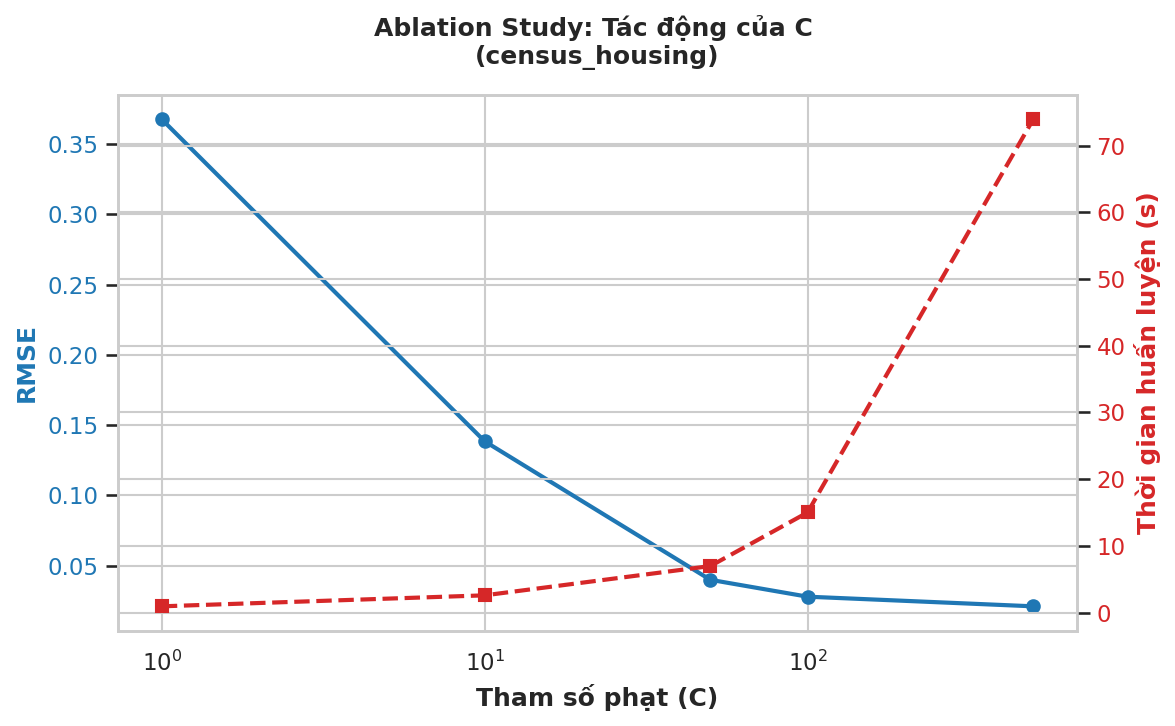

Đã lưu: /kaggle/working/experiments/data/ablation_results/plots/ablation_C.png


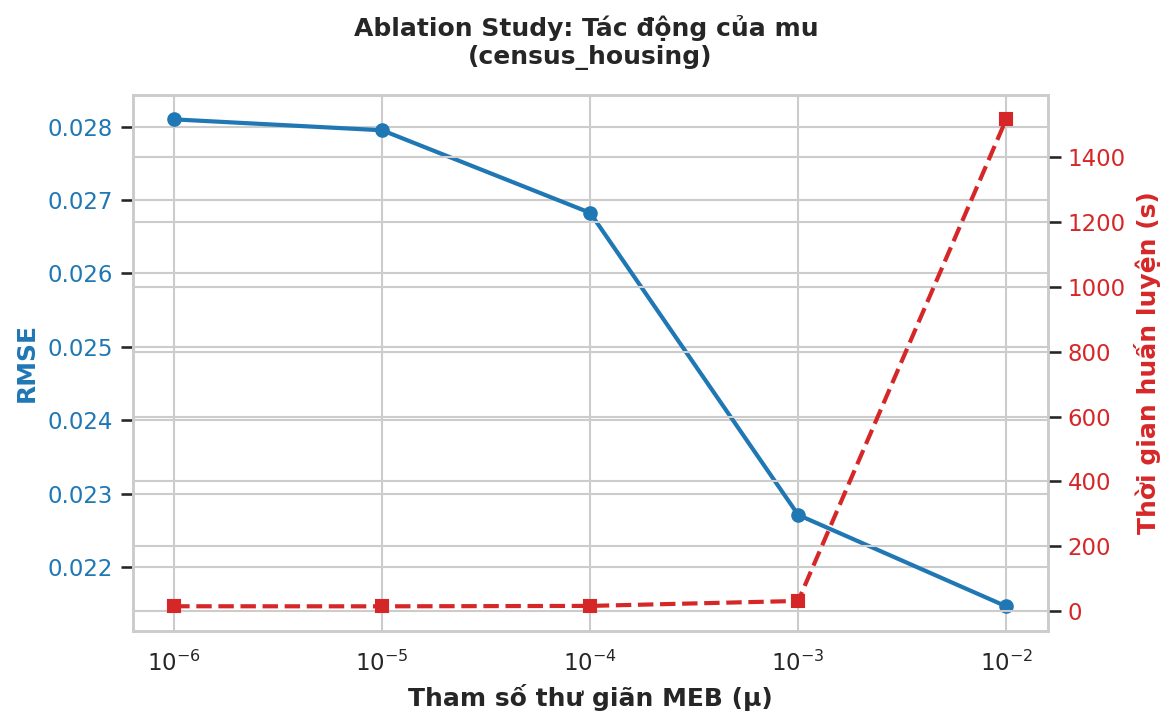

Đã lưu: /kaggle/working/experiments/data/ablation_results/plots/ablation_mu.png


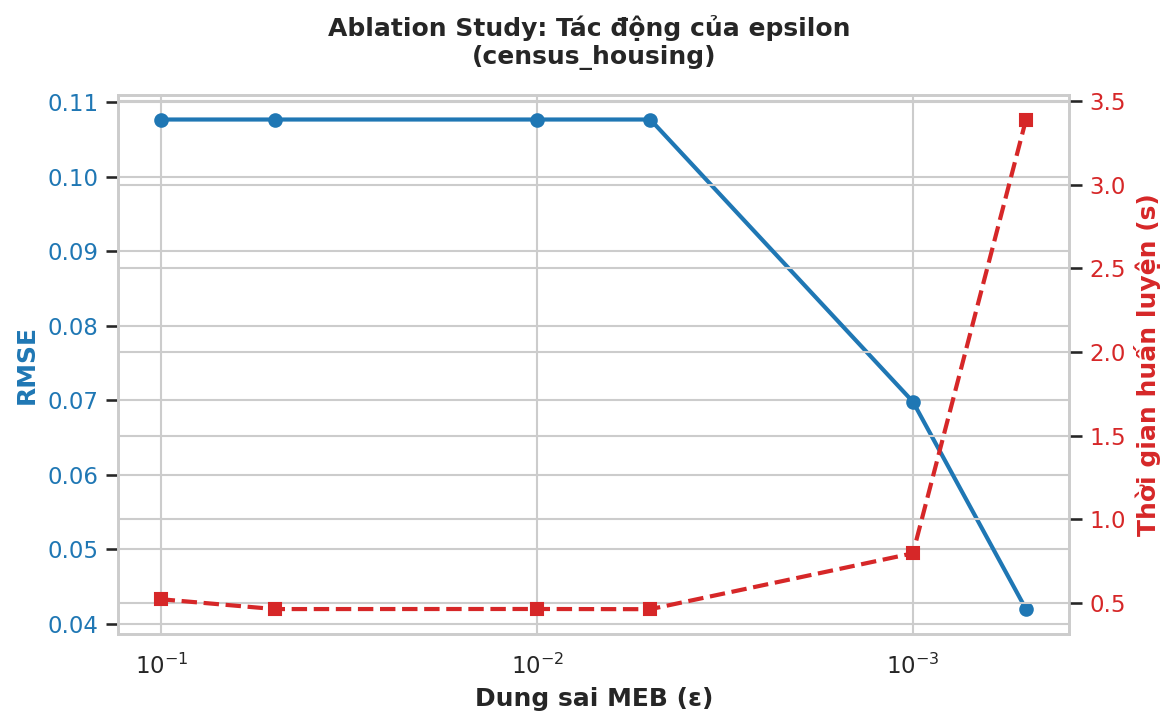

Đã lưu: /kaggle/working/experiments/data/ablation_results/plots/ablation_epsilon.png


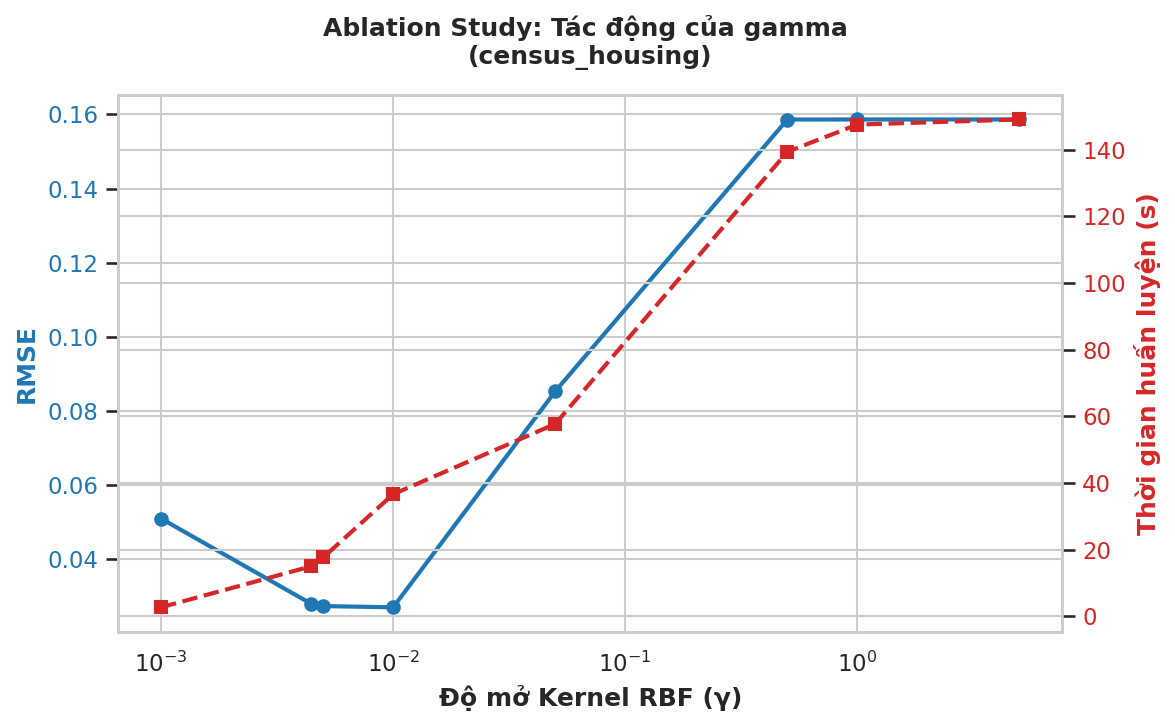

Đã lưu: /kaggle/working/experiments/data/ablation_results/plots/ablation_gamma.png


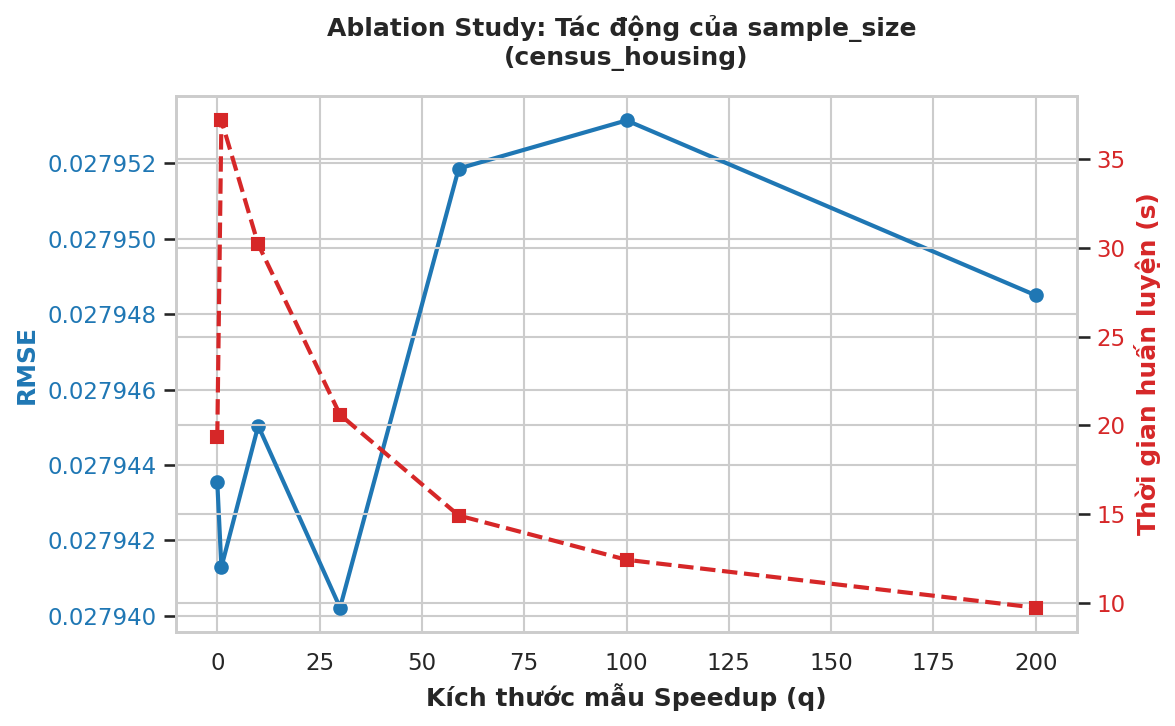

Đã lưu: /kaggle/working/experiments/data/ablation_results/plots/ablation_sample_size.png


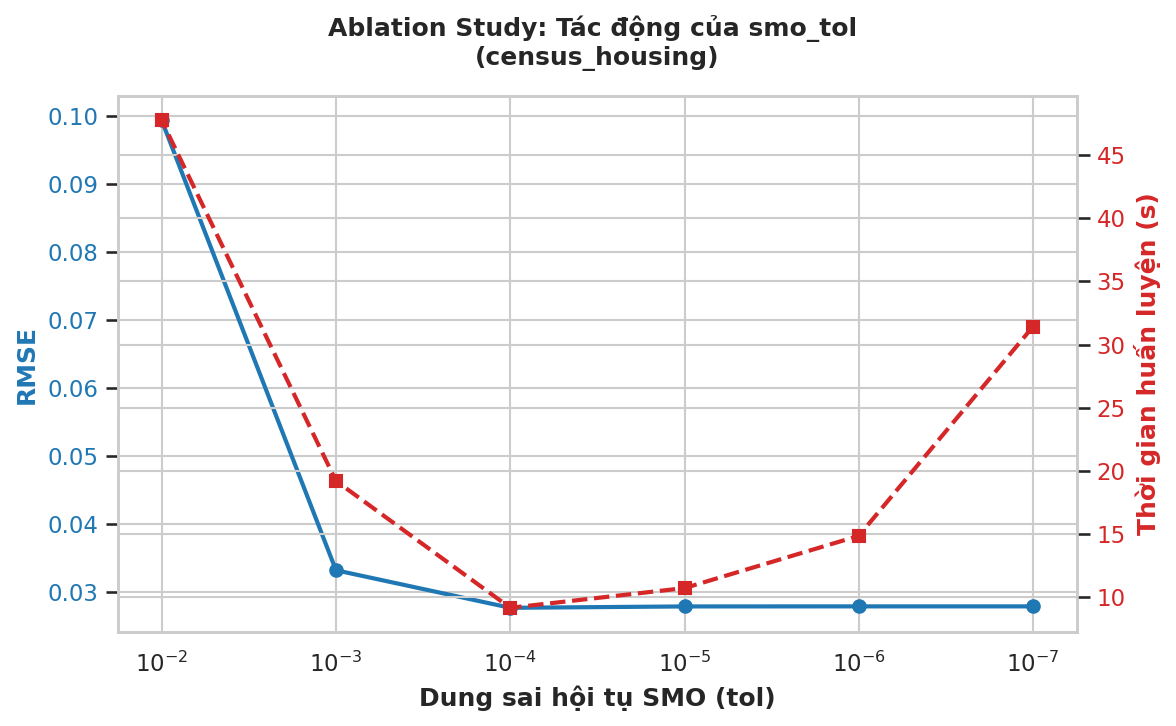

Đã lưu: /kaggle/working/experiments/data/ablation_results/plots/ablation_smo_tol.png


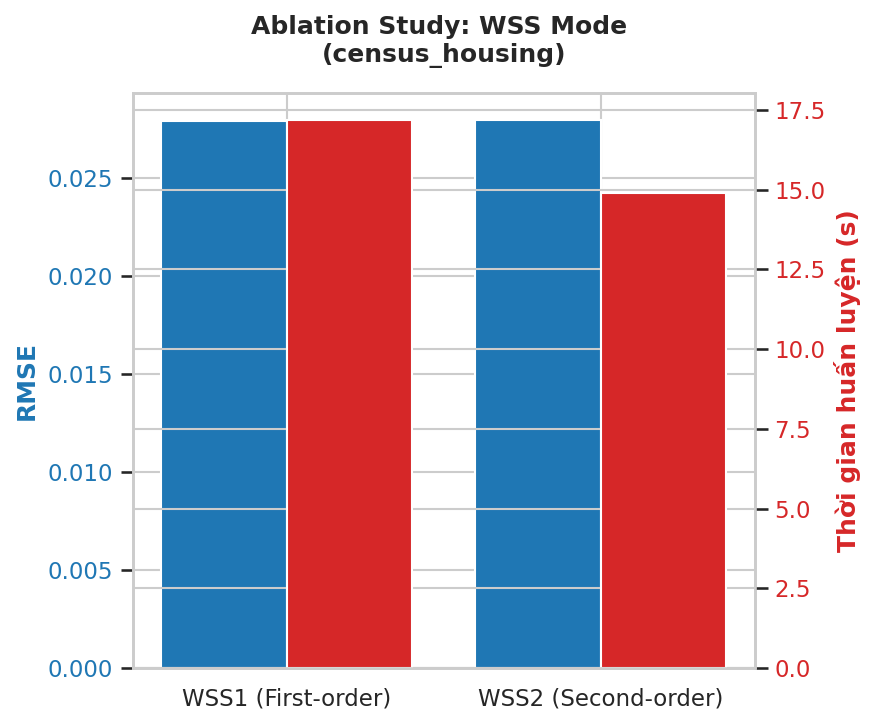

Đã lưu: /kaggle/working/experiments/data/ablation_results/plots/ablation_wss_mode.png


In [18]:
# Vẽ các biểu đồ thể hiện ảnh hưởng của từng tham số lên RMSE và Thời gian huấn luyện.

import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Thiết lập giao diện đẹp cho biểu đồ
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'font.size': 12, 'figure.dpi': 150})

# Thư mục lưu đồ thị (bạn chỉnh lại DATA_DIR theo môi trường Kaggle của bạn nếu cần)
try:
    RESULTS_DIR = os.path.join(DATA_DIR, "ablation_results")
except NameError:
    # Nếu chạy standalone không có DATA_DIR
    RESULTS_DIR = "/kaggle/working/experiments/data/ablation_results"

PLOTS_DIR = os.path.join(RESULTS_DIR, "plots")
os.makedirs(PLOTS_DIR, exist_ok=True)

csv_path = os.path.join(RESULTS_DIR, "ablation_all_datasets.csv")
if not os.path.exists(csv_path):
    print(f"Không tìm thấy file kết quả tại: {csv_path}")
else:
    df_all = pd.read_csv(csv_path)
    
    # Lọc dataset muốn vẽ (census_housing)
    dataset_name = "census_housing"
    df = df_all[df_all['dataset'] == dataset_name]

    print(f"Đang vẽ biểu đồ cho dataset: {dataset_name}")

    # Helper function để vẽ Line Chart 2 trục Y (RMSE và Time)
    def plot_ablation_line(df_sub, param, xlabel, xscale='log', reverse_x=False):
        if df_sub.empty: return
        
        # Sắp xếp trục X từ nhỏ đến lớn để đường vẽ không bị zigzag 
        df_sub = df_sub.sort_values(by='param_value') 
        
        fig, ax1 = plt.subplots(figsize=(8, 5))

        # Trục Y 1: RMSE (Màu xanh)
        color = 'tab:blue'
        ax1.set_xlabel(xlabel, fontweight='bold')
        ax1.set_ylabel('RMSE', color=color, fontweight='bold')
        ax1.plot(df_sub['param_value'], df_sub['rmse'], marker='o', linewidth=2, color=color, label='RMSE')
        ax1.tick_params(axis='y', labelcolor=color)
        if xscale == 'log':
            ax1.set_xscale('log')
        if reverse_x:
            ax1.invert_xaxis()

        # Trục Y 2: Time (Màu đỏ)
        ax2 = ax1.twinx()  
        color = 'tab:red'
        ax2.set_ylabel('Thời gian huấn luyện (s)', color=color, fontweight='bold')
        ax2.plot(df_sub['param_value'], df_sub['cpu_time'], marker='s', linestyle='--', linewidth=2, color=color, label='Time(s)')
        ax2.tick_params(axis='y', labelcolor=color)

        plt.title(f'Ablation Study: Tác động của {param} \n({dataset_name})', fontweight='bold', pad=15)
        fig.tight_layout()
        
        plot_path = os.path.join(PLOTS_DIR, f"ablation_{param}.png")
        plt.savefig(plot_path, bbox_inches='tight')
        plt.show()
        print(f"Đã lưu: {plot_path}")

    # 1. Vẽ Ablation C
    df_C = df[df['ablation'] == 'C'].copy()
    if not df_C.empty:
        df_C['param_value'] = df_C['param_value'].astype(float)
        plot_ablation_line(df_C, 'C', 'Tham số phạt (C)', xscale='log')

    # 2. Vẽ Ablation mu
    df_mu = df[df['ablation'] == 'mu'].copy()
    if not df_mu.empty:
        df_mu['param_value'] = df_mu['param_value'].astype(float)
        plot_ablation_line(df_mu, 'mu', 'Tham số thư giãn MEB (μ)', xscale='log')

    # 3. Vẽ Ablation epsilon
    df_eps = df[df['ablation'] == 'epsilon'].copy()
    if not df_eps.empty:
        df_eps['param_value'] = df_eps['param_value'].astype(float)
        plot_ablation_line(df_eps, 'epsilon', 'Dung sai MEB (ε)', xscale='log', reverse_x=True)

    # 4. Vẽ Ablation gamma
    df_gamma = df[df['ablation'] == 'gamma'].copy()
    if not df_gamma.empty:
        # Ghi đè param_value bằng giá trị numeric thực tế nằm trong cột 'gamma'
        df_gamma['param_value'] = df_gamma['gamma'].astype(float)
        plot_ablation_line(df_gamma, 'gamma', 'Độ mở Kernel RBF (γ)', xscale='log')

    # 5. Vẽ Ablation Sample Size (Probabilistic Speedup)
    df_sample = df[df['ablation'] == 'sample_size'].copy()
    if not df_sample.empty:
        df_sample['param_value'] = df_sample['param_value'].astype(float)
        plot_ablation_line(df_sample, 'sample_size', 'Kích thước mẫu Speedup (q)', xscale='linear')

    # 6. Vẽ Ablation SMO Tol
    df_smo = df[df['ablation'] == 'smo_tol'].copy()
    if not df_smo.empty:
        df_smo['param_value'] = df_smo['param_value'].astype(float)
        plot_ablation_line(df_smo, 'smo_tol', 'Dung sai hội tụ SMO (tol)', xscale='log', reverse_x=True)

    # 7. Vẽ Ablation WSS (Biểu đồ Cột)
    df_wss = df[df['ablation'] == 'wss_mode'].copy()
    if not df_wss.empty:
        fig, ax1 = plt.subplots(figsize=(6, 5))
        
        df_wss = df_wss.sort_values(by='param_value')
        labels = ['WSS1 (First-order)', 'WSS2 (Second-order)']
        x = range(len(labels))
        
        ax1.bar([i - 0.2 for i in x], df_wss['rmse'], width=0.4, color='tab:blue', label='RMSE')
        ax1.set_ylabel('RMSE', color='tab:blue', fontweight='bold')
        ax1.tick_params(axis='y', labelcolor='tab:blue')
        
        ax2 = ax1.twinx()
        ax2.bar([i + 0.2 for i in x], df_wss['cpu_time'], width=0.4, color='tab:red', label='Time (s)')
        ax2.set_ylabel('Thời gian huấn luyện (s)', color='tab:red', fontweight='bold')
        ax2.tick_params(axis='y', labelcolor='tab:red')
        
        plt.xticks(x, labels, fontweight='bold')
        plt.title(f'Ablation Study: WSS Mode \n({dataset_name})', fontweight='bold', pad=15)
        fig.tight_layout()
        
        plot_path = os.path.join(PLOTS_DIR, f"ablation_wss_mode.png")
        plt.savefig(plot_path, bbox_inches='tight')
        plt.show()
        print(f"Đã lưu: {plot_path}")